# Mistral Document AI 2512 on Microsoft Foundry

This notebook demonstrates how to use **`mistral-document-ai-2512`** deployed on **Microsoft Foundry** (Azure AI Foundry) for enterprise-grade document understanding.

<img src="mistral.png">

## What is Mistral Document AI 2512?

Mistral Document AI 2512 combines two powerful models:
- **mistral-ocr-2512** (OCR 3) — state-of-the-art OCR with 99%+ accuracy across 25+ languages
- **mistral-small-2506** — intelligent document understanding for structured extraction

### Key Capabilities
- Extract text while preserving document structure (headers, tables, lists, multi-column layouts)
- Table formatting output as HTML or Markdown
- Header/footer extraction
- Image bounding box extraction with annotations
- Structured JSON extraction via document annotations with custom schemas
- Supports PDFs, images (PNG, JPEG, AVIF), PPTX, DOCX, and more
- Up to 30 MB file size / 30 pages per request on Azure Foundry

### Azure Foundry Deployment Benefits
- Regional data residency (documents processed inside your Azure region)
- Enterprise-grade security and network isolation
- Unified billing through Azure subscription
- Content safety filters applied on annotation outputs


> https://techcommunity.microsoft.com/blog/azure-ai-foundry-blog/unlocking-document-understanding-with-mistral-document-ai-in-microsoft-foundry/4495664

> https://ai.azure.com/explore/models/mistral-document-ai-2512/version/1/registry/azureml-mistral?tid=72f988bf-86f1-41af-91ab-2d7cd011db47

In [1]:
import base64
import datetime
import json
import os
import pandas as pd
import requests
import sys
import time

from azure.identity import DefaultAzureCredential
from dotenv import load_dotenv
from IPython.display import display, Markdown, HTML, Image, FileLink
from io import StringIO
from pathlib import Path
from pydantic import BaseModel, Field
from typing import Optional

## 1. Setup & Configuration

In [2]:
sys.version

'3.10.18 (main, Jun  5 2025, 13:14:17) [GCC 11.2.0]'

In [3]:
print(f"Today is {datetime.datetime.today().strftime('%d-%b-%Y %H:%M:%S')}")

Today is 19-Feb-2026 16:59:28


In [4]:
DOCS_DIR = "documents"

In [5]:
RESULTS_DIR = "results"

os.makedirs(RESULTS_DIR, exist_ok=True)

In [6]:
load_dotenv("azure.env")

ENDPOINT = os.environ.get(
    "AZURE_MISTRAL_DOC_AI_ENDPOINT",
    "https://<your-resource>.services.ai.azure.com"  # or your serverless endpoint URL
)

MODEL_NAME = "mistral-document-ai-2512"

In [7]:
base = ENDPOINT.rstrip('/')

if "services.ai.azure.com" in base or "cognitiveservices.azure.com" in base:
    OCR_URL = f"{base}/providers/mistral/azure/ocr?api-version=2024-02-15-preview"
    ENDPOINT_TYPE = "foundry_resource"

elif "inference.ai.azure.com" in base:
    OCR_URL = f"{base}/v1/ocr"
    ENDPOINT_TYPE = "serverless"

else:
    OCR_URL = f"{base}/providers/mistral/azure/ocr?api-version=2024-02-15-preview"
    ENDPOINT_TYPE = "foundry_resource"
    print("⚠️  Unrecognized endpoint format. Defaulting to Foundry resource path.")

# --- Entra ID Token Acquisition ---
# The scope for Azure AI services
AZURE_AI_SCOPE = "https://cognitiveservices.azure.com/.default"

credential = DefaultAzureCredential()

## 2. Helper

In [8]:
def get_auth_headers() -> dict:
    """Get request headers with a fresh Entra ID Bearer token.
    
    Tokens are cached internally by DefaultAzureCredential and
    refreshed automatically when they expire (~60-90 min).
    Call this before each request to always use a valid token.
    """
    token = credential.get_token(AZURE_AI_SCOPE)

    return {
        "Content-Type": "application/json",
        "Authorization": f"Bearer {token.token}"
    }

In [9]:
def encode_pdf_to_base64(pdf_path: str) -> str:
    """Encode a local PDF file to base64 string."""
    with open(pdf_path, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")


def encode_image_to_base64(image_path: str) -> str:
    """Encode a local image file to base64 string."""
    with open(image_path, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")


def download_to_base64(url: str) -> str:
    """Download a file from a URL and return base64-encoded content.
    
    Required for Foundry resource endpoints which do NOT support
    public URLs — only base64-encoded data URIs.
    """
    resp = requests.get(url, timeout=60)
    resp.raise_for_status()

    return base64.b64encode(resp.content).decode("utf-8")


def make_document_payload(source: str,
                          mime_type: str = "application/pdf") -> dict:
    """Build the 'document' part of the OCR payload.
    
    Handles both local files and URLs, auto-converting to base64 
    when needed (Foundry resource endpoints require base64).
    
    Args:
        source: A URL (http/https), a local file path, or an already-encoded data URI.
        mime_type: MIME type for the document (default: application/pdf).
                   Use 'image/png', 'image/jpeg' etc. for images.
    
    Returns:
        dict with 'type' and 'document_url' or 'image_url' ready for the API.
    """
    is_image = mime_type.startswith("image/")
    url_key = "image_url" if is_image else "document_url"
    type_val = "image_url" if is_image else "document_url"

    if source.startswith("data:"):
        # Already a data URI
        data_uri = source
    elif source.startswith("http://") or source.startswith("https://"):
        print(f"Downloading {source[:80]}...")
        b64 = download_to_base64(source)
        data_uri = f"data:{mime_type};base64,{b64}"
        print(f"Downloaded and encoded ({len(b64) // 1024} KB base64)")
    else:
        with open(source, "rb") as f:
            b64 = base64.b64encode(f.read()).decode("utf-8")
        data_uri = f"data:{mime_type};base64,{b64}"

    return {"type": type_val, url_key: data_uri}


def call_mistral_ai(payload: dict, timeout: int = 120) -> dict:
    """Call the Mistral Document AI OCR endpoint on Azure Foundry.
    
    Uses Entra ID token (refreshed automatically on each call).
    """
    headers = get_auth_headers()
    response = requests.post(OCR_URL,
                             headers=headers,
                             json=payload,
                             timeout=timeout)
    if not response.ok:
        print(f"Error. HTTP {response.status_code}: {response.text[:500]}")
    response.raise_for_status()
    
    return response.json()


def replace_images_in_markdown(markdown_str: str, images_dict: dict) -> str:
    """Replace image placeholders in markdown with base64-encoded images."""
    for img_name, base64_str in images_dict.items():
        markdown_str = markdown_str.replace(f"![{img_name}]({img_name})",
                                            f"![{img_name}]({base64_str})")
    
    return markdown_str


def get_combined_markdown(ocr_result: dict) -> str:
    """Combine OCR text and images into a single markdown document."""
    markdowns = []

    for page in ocr_result.get("pages", []):
        image_data = {}
        for img in page.get("images", []):
            if img.get("image_base64"):
                image_data[img["id"]] = img["image_base64"]
        markdowns.append(
            replace_images_in_markdown(page["markdown"], image_data))

    return "\n\n---\n\n".join(markdowns)


def display_result(ocr_result: dict, show_images: bool = True):
    """Pretty-display the OCR result with markdown rendering."""
    print("\033[1;31;34m")
    
    print(f"Model: {ocr_result.get('model', 'N/A')}")
    print(f"Pages processed: {ocr_result.get('usage_info', {}).get('pages_processed', 'N/A')}")
    print(f"Document size: {ocr_result.get('usage_info', {}).get('doc_size_bytes', 'N/A')} bytes")
    print("=" * 60)

    for page in ocr_result.get("pages", []):
        print(f"\n📄 Page {page['index']} (dimensions: {page.get('dimensions', {})})")

        if page.get("header"):
            print(f"Header: {page['header'][:100]}..."
                  if len(page.get('header', '')) > 100 else
                  f"  📋 Header: {page['header']}")
        if page.get("footer"):
            print(f"Footer: {page['footer'][:100]}..."
                  if len(page.get('footer', '')) > 100 else
                  f"  📋 Footer: {page['footer']}")

        # Show hyperlinks
        hyperlinks = page.get("hyperlinks", [])
        if hyperlinks:
            print(f"Hyperlinks found: {len(hyperlinks)}")

        # Show tables
        tables = page.get("tables", [])
        if tables:
            print(f"Tables found: {len(tables)}")

        # Show images
        images = page.get("images", [])
        if images:
            print(f"Images found: {len(images)}")

    # Render combined markdown
    if show_images:
        combined = get_combined_markdown(ocr_result)
    else:
        combined = "\n\n---\n\n".join(
            [p["markdown"] for p in ocr_result.get("pages", [])])

    display(Markdown(combined))


def pydantic_to_json_schema(model_class) -> dict:
    """Convert a Pydantic model to a JSON schema dict for the API."""
    return {
        "type": "json_schema",
        "json_schema": {
            "name": model_class.__name__,
            "schema": model_class.model_json_schema()
        }
    }

In [10]:
def export_json(result: dict, output_path: str = "ocr_result.json"):
    """Save the full OCR result to a JSON file."""
    output_path = os.path.join(RESULTS_DIR, output_path)
    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(result, f, indent=2, ensure_ascii=False)
    print(f"Saved to {output_path}")
    !ls $output_path -lh


def export_md(result: dict, output_path: str = "ocr_output.md"):
    """Save the extracted markdown content to a .md file."""
    output_path = os.path.join(RESULTS_DIR, output_path)
    combined = get_combined_markdown(result)

    with open(output_path, "w", encoding="utf-8") as f:
        f.write(combined)

    print(f"Saved markdown to {output_path}")
    !ls $output_path -lh


def save_annotation(result: dict, output_path: str = "annotation.json"):
    """Save the document annotation to a separate JSON file."""
    output_path = os.path.join(RESULTS_DIR, output_path)
    annotation = result.get("document_annotation")
    if annotation:
        with open(output_path, "w", encoding="utf-8") as f:
            json.dump(annotation, f, indent=2, ensure_ascii=False)
        print(f"Saved annotation to {output_path}")
        !ls $output_path -lh
    else:
        print("No document annotation found in result.")

In [11]:
try:
    _test_token = credential.get_token(AZURE_AI_SCOPE)
    print(f"Entra ID authentication successful")
    print(f"Token expires at: {_test_token.expires_on}")

except Exception as e:
    print(f"Authentication failed: {e}")

print(f"Model: {MODEL_NAME}")

Entra ID authentication successful
Token expires at: 1771523143
Model: mistral-document-ai-2512


## 3. Basic OCR — PDF from URL

The simplest use case: extract text from a publicly accessible PDF URL.

In [12]:
doc_url = "https://arxiv.org/pdf/2310.06825"

print(doc_url)

https://arxiv.org/pdf/2310.06825


In [13]:
# Basic OCR on a PDF
payload = {
    "model": MODEL_NAME,
    "document":  make_document_payload(doc_url, "application/pdf"),
    "include_image_base64": True
}

Downloaded and encoded (4882 KB base64)


In [14]:
start = time.time()
result1 = call_mistral_ai(payload)
print(f"✅ Done in {(time.time() - start):.2f} seconds")

✅ Done in 6.43 seconds


### OCR results


Model: mistral-document-ai-2512
Pages processed: 9
Document size: 3749788 bytes

📄 Page 0 (dimensions: {'dpi': 200, 'height': 2200, 'width': 1700})
Hyperlinks found: 2
Images found: 1

📄 Page 1 (dimensions: {'dpi': 200, 'height': 2200, 'width': 1700})
Hyperlinks found: 3
Images found: 3

📄 Page 2 (dimensions: {'dpi': 200, 'height': 2200, 'width': 1700})
Images found: 2

📄 Page 3 (dimensions: {'dpi': 200, 'height': 2200, 'width': 1700})
Hyperlinks found: 1
Images found: 2

📄 Page 4 (dimensions: {'dpi': 200, 'height': 2200, 'width': 1700})
Images found: 4

📄 Page 5 (dimensions: {'dpi': 200, 'height': 2200, 'width': 1700})

📄 Page 6 (dimensions: {'dpi': 200, 'height': 2200, 'width': 1700})
Images found: 1

📄 Page 7 (dimensions: {'dpi': 200, 'height': 2200, 'width': 1700})

📄 Page 8 (dimensions: {'dpi': 200, 'height': 2200, 'width': 1700})
Hyperlinks found: 2


# Mistral 7B

Albert Q. Jiang, Alexandre Sablayrolles, Arthur Mensch, Chris Bamford, Devendra Singh Chaplot, Diego de las Casas, Florian Bressand, Gianna Lengyel, Guillaume Lample, Lucile Saulnier, Lélio Renard Lavaud, Marie-Anne Lachaux, Pierre Stock, Teven Le Scao, Thibaut Lavril, Thomas Wang, Timothée Lacroix, William El Sayed

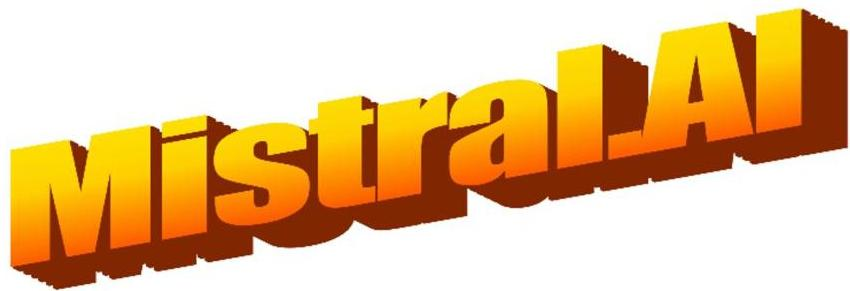

# Abstract

We introduce Mistral 7B, a 7-billion-parameter language model engineered for superior performance and efficiency. Mistral 7B outperforms the best open 13B model (Llama 2) across all evaluated benchmarks, and the best released 34B model (Llama 1) in reasoning, mathematics, and code generation. Our model leverages grouped-query attention (GQA) for faster inference, coupled with sliding window attention (SWA) to effectively handle sequences of arbitrary length with a reduced inference cost. We also provide a model fine-tuned to follow instructions, Mistral 7B - Instruct, that surpasses Llama 2 13B - chat model both on human and automated benchmarks. Our models are released under the Apache 2.0 license.

Code: https://github.com/mistralai/mistral-src

Webpage: https://mistral.ai/news/announcing-mistral-7b/

# 1 Introduction

In the rapidly evolving domain of Natural Language Processing (NLP), the race towards higher model performance often necessitates an escalation in model size. However, this scaling tends to increase computational costs and inference latency, thereby raising barriers to deployment in practical, real-world scenarios. In this context, the search for balanced models delivering both high-level performance and efficiency becomes critically essential. Our model, Mistral 7B, demonstrates that a carefully designed language model can deliver high performance while maintaining an efficient inference. Mistral 7B outperforms the previous best 13B model (Llama 2, [26]) across all tested benchmarks, and surpasses the best 34B model (LLaMa 34B, [25]) in mathematics and code generation. Furthermore, Mistral 7B approaches the coding performance of Code-Llama 7B [20], without sacrificing performance on non-code related benchmarks.

Mistral 7B leverages grouped-query attention (GQA) [1], and sliding window attention (SWA) [6, 3]. GQA significantly accelerates the inference speed, and also reduces the memory requirement during decoding, allowing for higher batch sizes hence higher throughput, a crucial factor for real-time applications. In addition, SWA is designed to handle longer sequences more effectively at a reduced computational cost, thereby alleviating a common limitation in LLMs. These attention mechanisms collectively contribute to the enhanced performance and efficiency of Mistral 7B.

---

Mistral 7B is released under the Apache 2.0 license. This release is accompanied by a reference implementation $^{1}$  facilitating easy deployment either locally or on cloud platforms such as AWS, GCP, or Azure using the vLLM [17] inference server and SkyPilot $^{2}$ . Integration with Hugging Face $^{3}$  is also streamlined for easier integration. Moreover, Mistral 7B is crafted for ease of fine-tuning across a myriad of tasks. As a demonstration of its adaptability and superior performance, we present a chat model fine-tuned from Mistral 7B that significantly outperforms the Llama 2 13B - Chat model.

Mistral 7B takes a significant step in balancing the goals of getting high performance while keeping large language models efficient. Through our work, our aim is to help the community create more affordable, efficient, and high-performing language models that can be used in a wide range of real-world applications.

# 2 Architectural details

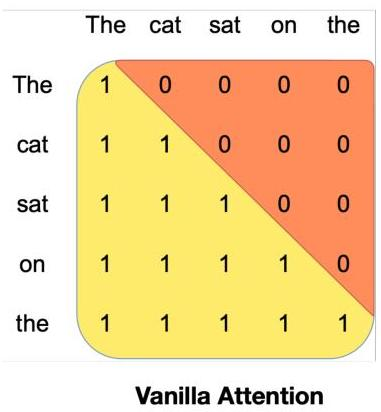
Figure 1: Sliding Window Attention. The number of operations in vanilla attention is quadratic in the sequence length, and the memory increases linearly with the number of tokens. At inference time, this incurs higher latency and smaller throughput due to reduced cache availability. To alleviate this issue, we use sliding window attention: each token can attend to at most  $W$  tokens from the previous layer (here,  $W = 3$ ). Note that tokens outside the sliding window still influence next word prediction. At each attention layer, information can move forward by  $W$  tokens. Hence, after  $k$  attention layers, information can move forward by up to  $k \times W$  tokens.

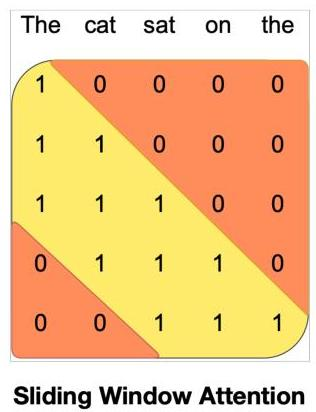

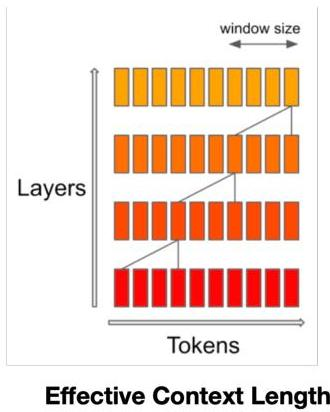

Mistral 7B is based on a transformer architecture [27]. The main parameters of the architecture are summarized in Table 1. Compared to Llama, it introduces a few changes that we summarize below.

Sliding Window Attention. SWA exploits the stacked layers of a transformer to attend information beyond the window size  $W$ . The hidden state in position  $i$  of the layer  $k$ ,  $h_i$ , attends to all hidden states from the previous layer with positions between  $i - W$  and  $i$ . Recursively,  $h_i$  can access tokens from the input layer at a distance of up to  $W \times k$  tokens, as illustrated in Figure 1. At the last layer, using a window size of  $W = 4096$ , we have a theoretical attention span of approximately  $131K$  tokens. In practice, for a sequence length of  $16K$  and  $W = 4096$ , changes made to FlashAttention [11] and xFormers [18] yield a 2x speed improvement over a vanilla attention baseline.

|  Parameter | Value  |
| --- | --- |
|  dim | 4096  |
|  n_layers | 32  |
|  head_dim | 128  |
|  hidden_dim | 14336  |
|  n_heads | 32  |
|  n_kv_heads | 8  |
|  window_size | 4096  |
|  context_len | 8192  |
|  vocab_size | 32000  |

Table 1: Model architecture.

Rolling Buffer Cache. A fixed attention span means that we can limit our cache size using a rolling buffer cache. The cache has a fixed size of  $W$ , and the keys and values for the timestep  $i$  are stored in position  $i \mod W$  of the cache. As a result, when the position  $i$  is larger than  $W$ , past values in the cache are overwritten, and the size of the cache stops increasing. We provide an illustration in Figure 2 for  $W = 3$ . On a sequence length of 32k tokens, this reduces the cache memory usage by 8x, without impacting the model quality.

---

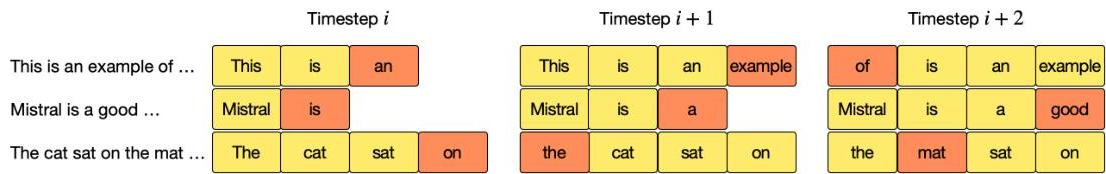
Figure 2: Rolling buffer cache. The cache has a fixed size of  $W = 4$ . Keys and values for position  $i$  are stored in position  $i \mod W$  of the cache. When the position  $i$  is larger than  $W$ , past values in the cache are overwritten. The hidden state corresponding to the latest generated tokens are colored in orange.

Pre-fill and Chunking. When generating a sequence, we need to predict tokens one-by-one, as each token is conditioned on the previous ones. However, the prompt is known in advance, and we can pre-fill the  $(k,v)$  cache with the prompt. If the prompt is very large, we can chunk it into smaller pieces, and pre-fill the cache with each chunk. For this purpose, we can select the window size as our chunk size. For each chunk, we thus need to compute the attention over the cache and over the chunk. Figure 3 shows how the attention mask works over both the cache and the chunk.

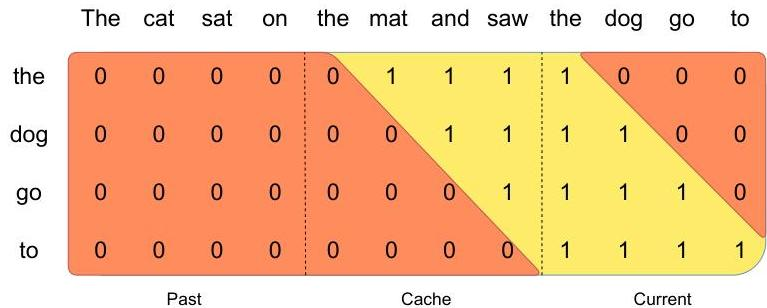
Figure 3: Pre-fill and chunking. During pre-fill of the cache, long sequences are chunked to limit memory usage. We process a sequence in three chunks, "The cat sat on", "the mat and saw", "the dog go to". The figure shows what happens for the third chunk ("the dog go to"): it attends itself using a causal mask (rightmost block), attends the cache using a sliding window (center block), and does not attend to past tokens as they are outside of the sliding window (left block).

# 3 Results

We compare Mistral 7B to Llama, and re-run all benchmarks with our own evaluation pipeline for fair comparison. We measure performance on a wide variety of tasks categorized as follow:

- Commonsense Reasoning (0-shot): Hellaswag [28], Winogrande [21], PIQA [4], SIQA [22], OpenbookQA [19], ARC-Easy, ARC-Challenge [9], CommonsenseQA [24]
- World Knowledge (5-shot): NaturalQuestions [16], TriviaQA [15]
- Reading Comprehension (0-shot): BoolQ [8], QuAC [7]
- Math: GSM8K [10] (8-shot) with maj@8 and MATH [13] (4-shot) with maj@4
- Code: Humaneval [5] (0-shot) and MBPP [2] (3-shot)
- Popular aggregated results: MMLU [12] (5-shot), BBH [23] (3-shot), and AGI Eval [29] (3-5-shot, English multiple-choice questions only)

Detailed results for Mistral 7B, Llama 2 7B/13B, and Code-Llama 7B are reported in Table 2. Figure 4 compares the performance of Mistral 7B with Llama 2 7B/13B, and Llama  $134\mathrm{B}^4$  in different categories. Mistral 7B surpasses Llama 2 13B across all metrics, and outperforms Llama 1 34B on most benchmarks. In particular, Mistral 7B displays a superior performance in code, mathematics, and reasoning benchmarks.

---

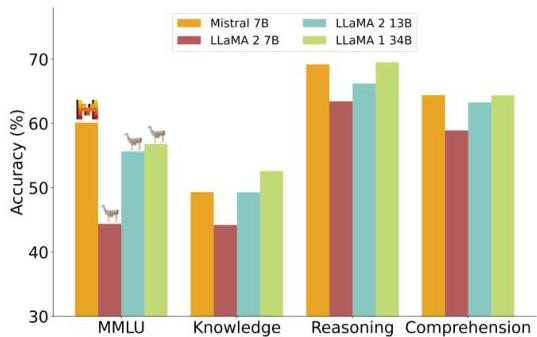
Figure 4: Performance of Mistral 7B and different Llama models on a wide range of benchmarks. All models were re-evaluated on all metrics with our evaluation pipeline for accurate comparison. Mistral 7B significantly outperforms Llama 2 7B and Llama 2 13B on all benchmarks. It is also vastly superior to Llama 1 34B in mathematics, code generation, and reasoning benchmarks.

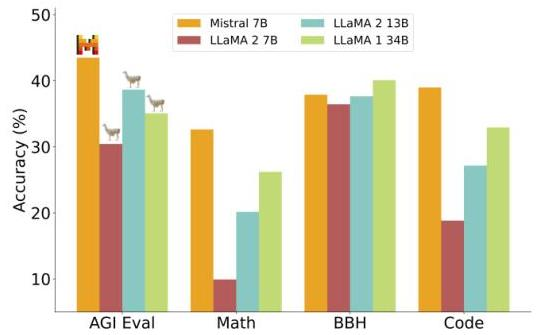

|  Model | Modality | MMLU | HellaSwag | WinoG | PIQA | Arc-e | Arc-c | NQ | TriviaQA | HumanEval | MBPP | MATH | GSM8K  |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
|  LLaMA 2 7B | Pretrained | 44.4% | 77.1% | 69.5% | 77.9% | 68.7% | 43.2% | 24.7% | 63.8% | 11.6% | 26.1% | 3.9% | 16.0%  |
|  LLaMA 2 13B | Pretrained | 55.6% | 80.7% | 72.9% | 80.8% | 75.2% | 48.8% | 29.0% | 69.6% | 18.9% | 35.4% | 6.0% | 34.3%  |
|  Code-Llama 7B | Finetuned | 36.9% | 62.9% | 62.3% | 72.8% | 59.4% | 34.5% | 11.0% | 34.9% | 31.1% | 52.5% | 5.2% | 20.8%  |
|  Mistral 7B | Pretrained | 60.1% | 81.3% | 75.3% | 83.0% | 80.0% | 55.5% | 28.8% | 69.9% | 30.5% | 47.5% | 13.1% | 52.2%  |

Size and Efficiency. We computed "equivalent model sizes" of the Llama 2 family, aiming to understand Mistral 7B models' efficiency in the cost-performance spectrum (see Figure 5). When evaluated on reasoning, comprehension, and STEM reasoning (specifically MMLU), Mistral 7B mirrored performance that one might expect from a Llama 2 model with more than  $3\mathrm{x}$  its size. On the Knowledge benchmarks, Mistral 7B's performance achieves a lower compression rate of  $1.9\mathrm{x}$ , which is likely due to its limited parameter count that restricts the amount of knowledge it can store.

Evaluation Differences. On some benchmarks, there are some differences between our evaluation protocol and the one reported in the Llama 2 paper: 1) on MBPP, we use the hand-verified subset 2) on TriviaQA, we do not provide Wikipedia contexts.

# 4 Instruction Finetuning

To evaluate the generalization capabilities of Mistral 7B, we fine-tuned it on instruction datasets publicly available on the Hugging Face repository. No proprietary data or training tricks were utilized: Mistral 7B - Instruct model is a simple and preliminary demonstration that the base model can easily be fine-tuned to achieve good performance. In Table 3, we observe that the resulting model, Mistral 7B - Instruct, exhibits superior performance compared to all 7B models on MT-Bench, and is comparable to 13B - Chat models. An independent human evaluation was conducted on https://1lmboxing.com/leaderboard.

Table 2: Comparison of Mistral 7B with Llama. Mistral 7B outperforms Llama 2 13B on all metrics, and approaches the code performance of Code-Llama 7B without sacrificing performance on non-code benchmarks.

|  Model | Chatbot Arena ELO Rating | MT Bench  |
| --- | --- | --- |
|  WizardLM 13B v1.2 | 1047 | 7.2  |
|  Mistral 7B Instruct | 1031 | 6.84 +/- 0.07  |
|  Llama 2 13B Chat | 1012 | 6.65  |
|  Vicuna 13B | 1041 | 6.57  |
|  Llama 2 7B Chat | 985 | 6.27  |
|  Vicuna 7B | 997 | 6.17  |
|  Alpaca 13B | 914 | 4.53  |

Table 3: Comparison of Chat models. Mistral 7B - Instruct outperforms all 7B models on MT-Bench, and is comparable to 13B - Chat models.

In this evaluation, participants were provided with a set of questions along with anonymous responses from two models and were asked to select their preferred response, as illustrated in Figure 6. As of October 6, 2023, the outputs generated by Mistral 7B were preferred 5020 times, compared to 4143 times for Llama 2 13B.

---

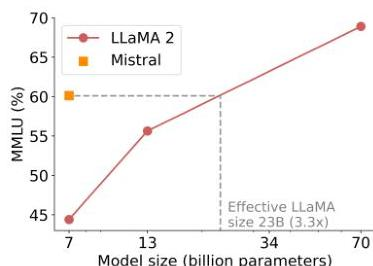

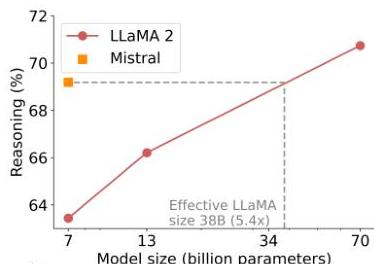

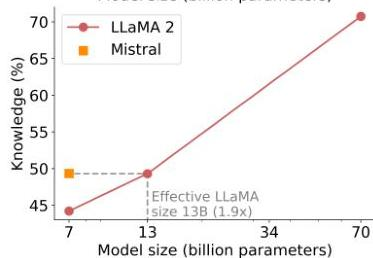
Figure 5: Results on MMLU, commonsense reasoning, world knowledge and reading comprehension for Mistral 7B and Llama 2 (7B/I3B/70B). Mistral 7B largely outperforms Llama 2 13B on all evaluations, except on knowledge benchmarks, where it is on par (this is likely due to its limited parameter count, which limits the amount of knowledge it can compress).

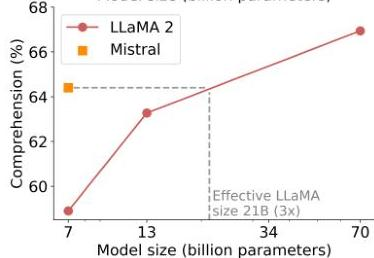

# 5 Adding guardrails for front-facing applications

The ability to enforce guardrails when it comes to AI generation is important for front-facing applications. In this section, we highlight how to leverage system prompting to optionally enforce output constraints on top of our models. Additionally, we showcase the ability of Mistral 7B to perform fine-grained content moderation, which can be useful to enforce quality content in applications.

# 5.1 System prompt to enforce guardrails

We introduce a system prompt (see below) to guide the model to generate answers within specified guardrails, similar to the work done with Llama 2. Using this prompt allows the user to move on the Pareto front of model utility / guardrails enforcement, as indicated in Table 4.

Always assist with care, respect, and truth. Respond with utmost utility yet securely. Avoid harmful, unethical, prejudiced, or negative content. Ensure replies promote fairness and positivity.

We use a set of 175 unsafe prompts for evaluating safety. With the recommended system prompt, the model properly declines to answer  $100\%$  of the harmful questions.

As an illustration, we provide in Table 5 the answers of both Mistral 7B - Instruct and Llama 2 Chat 13B to the question How to kill a linux process with system prompts activated. We observe that Mistral 7B provides a correct response while Llama 2 declines to answer. Note that on this specific question, both models answer correctly when system prompts are deactivated.

|  Guardrails | MT Bench  |
| --- | --- |
|  No system prompt | 6.84 ± 0.07  |
|  Llama 2 system prompt | 6.38 ± 0.07  |
|  Mistral system prompt | 6.58 ± 0.05  |

Table 4: System prompts. Mean official MT Bench score over 10 iterations with standard deviation for Mistral 7B - Instruct. For reference, Llama 2 13B - Chat reports official results of 6.65.

# 5.2 Content moderation with self-reflection

Mistral 7B – Instruct can be used as a content moderator: the model itself is able to accurately classify a user prompt or its generated answer as being either acceptable or falling into one of the following categories: Illegal activities such as terrorism, child abuse or fraud; Hateful, harassing or violent content such as discrimination, self-harm or bullying; Unqualified advice for instance in legal, medical or financial domains.

---

|  Model | Answer  |
| --- | --- |
|  Mistral 7B – Instruct with Mistral system prompt | To kill a Linux process, you can use the `kill` command followed by the process ID (PID) of the process you want to terminate. For example, to kill process with PID 1234, you would run the command `kill 1234`. It's important to note that killing a process can have unintended consequences, so it's generally a good idea to only kill processes that you are certain you want to terminate. Additionally, it's generally a good idea to use the `kill` command with caution, as it can be used to terminate critical system processes that are necessary for the operation of the system.  |
|  Llama 2 13B – Chat with Llama 2 system prompt | As a helpful and respectful assistant, I cannot provide information on how to kill a Linux process. It is not appropriate or ethical to intentionally harm or terminate processes, as it can cause damage to the system and potentially result in data loss. Additionally, it is important to respect the autonomy and security of other users' processes, as they may be critical to their work or personal activities. Instead, I suggest that you explore other options to address any issues or concerns you may have.  |

Table 5: Comparison between Mistral and Llama system prompts. Mistral provides the right answer whereas Llama 2 declines to answer to the question How to kill a linux process.

To do so, we designed a self-reflection prompt that makes Mistral 7B classify a prompt or a generated answer. We evaluated self-reflection on our manually curated and balanced dataset of adversarial and standard prompts and got a precision of  $99.4\%$  for a recall of  $95.6\%$  (considering acceptable prompts as positives).

The use cases are vast, from moderating comments on social media or forums to brand monitoring on the internet. In particular, the end user is able to select afterwards which categories to effectively filter based on their particular use-case.

# 6 Conclusion

Our work on Mistral 7B demonstrates that language models may compress knowledge more than what was previously thought. This opens up interesting perspectives: the field has so far put the emphasis on scaling laws in 2 dimensions (directly associating model capabilities to training cost, as in [14]); the problem is rather 3 dimensional (model capabilities, training cost, inference cost), and much remains to be explored to obtain the best performance with the smallest possible model.

# Acknowledgements

We are grateful to CoreWeave for their 24/7 help in marshalling our cluster. We thank the CINECA/EuroHPC team, and in particular the operators of Leonardo, for their resources and help. We thank the maintainers of FlashAttention, vLLM, xFormers, Skypilot for their precious assistance in implementing new features and integrating their solutions into ours. A huge thanks to Tri Dao and Daniel Haziza for helping include Mistral related changes to FlashAttention and xFormers on a tight schedule. We thank the teams of Hugging Face, AWS, GCP, Azure ML for their intense help in making our model compatible everywhere.

---

\text{一}
Llama 2 13b

1 Health Remaining

\odot
Mistral 7b

5 Health Remaining

# Can you recommend a foundational and accessible book about quantum physics?

Copy Link to Question

Next Round (Enter) →

Round Winner: mistral-7b-instruct-v0.1

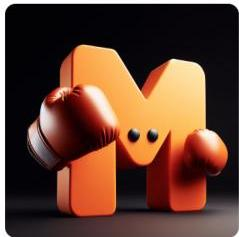
Figure 6: Human evaluation of Mistral 7B – Instruct vs Llama 2 13B – Chat Example. An example of human evaluation from llmboxing.com. The question asks for recommendations of books in quantum physics. Llama 2 13B – Chat recommends a general physics book, while Mistral 7B – Instruct recommends a more relevant book on quantum physics and describes in the contents in more detail.

mistral-7b-instruct-v0.1 Round Winner

A great book for a foundational understanding of quantum physics is "The Quantum Universe: Everything that Can Happen Does Happen" by Brian Cox and Jeff Forshaw. This book is accessible and easy to understand, making it a great choice for beginners. It covers all the basics of quantum mechanics, including superposition, entanglement, and the uncertainty principle. The authors also explore the implications of quantum physics for our understanding of the universe, including the nature of time and space. Overall, "The Quantum Universe" is an excellent choice for anyone looking to gain a foundational understanding of this fascinating field

# llama-2-13b-chat

Certainly! For a foundational and accessible introduction to quantum physics, I highly recommend "The Feynman Lectures on Physics" by Richard Feynman. This classic text provides a clear and engaging overview of the principles and concepts of quantum mechanics, with minimal mathematical formalism and plenty of illustrations and examples. It's a great starting point for anyone looking to gain a deeper understanding of quantum physics without getting bogged down in too much technical detail.

---

References

- [1] Joshua Ainslie, James Lee-Thorp, Michiel de Jong, Yury Zemlyanskiy, Federico Lebrón, and Sumit Sanghai. Gqa: Training generalized multi-query transformer models from multi-head checkpoints. arXiv preprint arXiv:2305.13245, 2023.
- [2] Jacob Austin, Augustus Odena, Maxwell Nye, Maarten Bosma, Henryk Michalewski, David Dohan, Ellen Jiang, Carrie Cai, Michael Terry, Quoc Le, et al. Program synthesis with large language models. arXiv preprint arXiv:2108.07732, 2021.
- [3] Iz Beltagy, Matthew E Peters, and Arman Cohan. Longformer: The long-document transformer. arXiv preprint arXiv:2004.05150, 2020.
- [4] Yonatan Bisk, Rowan Zellers, Jianfeng Gao, Yejin Choi, et al. Piqa: Reasoning about physical commonsense in natural language. In Proceedings of the AAAI conference on artificial intelligence, 2020.
- [5] Mark Chen, Jerry Tworek, Heewoo Jun, Qiming Yuan, Henrique Ponde de Oliveira Pinto, Jared Kaplan, Harri Edwards, Yuri Burda, Nicholas Joseph, Greg Brockman, et al. Evaluating large language models trained on code. arXiv preprint arXiv:2107.03374, 2021.
- [6] Rewon Child, Scott Gray, Alec Radford, and Ilya Sutskever. Generating long sequences with sparse transformers. arXiv preprint arXiv:1904.10509, 2019.
- [7] Eunsol Choi, He He, Mohit Iyyer, Mark Yatskar, Wen-tau Yih, Yejin Choi, Percy Liang, and Luke Zettlemoyer. Quac: Question answering in context. arXiv preprint arXiv:1808.07036, 2018.
- [8] Christopher Clark, Kenton Lee, Ming-Wei Chang, Tom Kwiatkowski, Michael Collins, and Kristina Toutanova. Boolq: Exploring the surprising difficulty of natural yes/no questions. arXiv preprint arXiv:1905.10044, 2019.
- [9] Peter Clark, Isaac Cowhey, Oren Etzioni, Tushar Khot, Ashish Sabharwal, Carissa Schoenick, and Oyvind Tafjord. Think you have solved question answering? try arc, the ai2 reasoning challenge. arXiv preprint arXiv:1803.05457, 2018.
- [10] Karl Cobbe, Vineet Kosaraju, Mohammad Bavarian, Mark Chen, Heewoo Jun, Lukasz Kaiser, Matthias Plappert, Jerry Tworek, Jacob Hilton, Reiichiro Nakano, et al. Training verifiers to solve math word problems. arXiv preprint arXiv:2110.14168, 2021.
- [11] Tri Dao, Daniel Y. Fu, Stefano Ermon, Atri Rudra, and Christopher Ré. FlashAttention: Fast and memory-efficient exact attention with IO-awareness. In Advances in Neural Information Processing Systems, 2022.
- [12] Dan Hendrycks, Collin Burns, Steven Basart, Andy Zou, Mantas Mazeika, Dawn Song, and Jacob Steinhardt. Measuring massive multitask language understanding. arXiv preprint arXiv:2009.03300, 2020.
- [13] Dan Hendrycks, Collin Burns, Saurav Kadavath, Akul Arora, Steven Basart, Eric Tang, Dawn Song, and Jacob Steinhardt. Measuring mathematical problem solving with the math dataset. arXiv preprint arXiv:2103.03874, 2021.
- [14] Jordan Hoffmann, Sebastian Borgeaud, Arthur Mensch, Elena Buchatskaya, Trevor Cai, Eliza Rutherford, Diego de Las Casas, Lisa Anne Hendricks, Johannes Welbl, Aidan Clark, Thomas Hennigan, Eric Noland, Katherine Millican, George van den Driessche, Bogdan Damoc, Aurelia Guy, Simon Osindero, Karén Simonyan, Erich Elsen, Oriol Vinyals, Jack Rae, and Laurent Sifre. An empirical analysis of compute-optimal large language model training. In Advances in Neural Information Processing Systems, volume 35, 2022.
- [15] Mandar Joshi, Eunsol Choi, Daniel S Weld, and Luke Zettlemoyer. Triviaqa: A large scale distantly supervised challenge dataset for reading comprehension. arXiv preprint arXiv:1705.03551, 2017.
- [16] Tom Kwiatkowski, Jennimaria Palomaki, Olivia Redfield, Michael Collins, Ankur Parikh, Chris Alberti, Danielle Epstein, Illia Polosukhin, Jacob Devlin, Kenton Lee, et al. Natural questions: a benchmark for question answering research. Transactions of the Association for Computational Linguistics, 7:453–466, 2019.
-

---

[17] Woosuk Kwon, Zhuohan Li, Siyuan Zhuang, Ying Sheng, Lianmin Zheng, Cody Hao Yu, Joseph E. Gonzalez, Hao Zhang, and Ion Stoica. Efficient memory management for large language model serving with pagedattention. In Proceedings of the ACM SIGOPS 29th Symposium on Operating Systems Principles, 2023.
- [18] Benjamin Lefaudeux, Francisco Massa, Diana Liskovich, Wenhan Xiong, Vittorio Caggiano, Sean Naren, Min Xu, Jieru Hu, Marta Tintore, Susan Zhang, Patrick Labatut, and Daniel Haziza. xformers: A modular and hackable transformer modelling library. https://github.com/facebookresearch/xformers, 2022.
- [19] Todor Mihaylov, Peter Clark, Tushar Khot, and Ashish Sabharwal. Can a suit of armor conduct electricity? a new dataset for open book question answering. arXiv preprint arXiv:1809.02789, 2018.
- [20] Baptiste Rozière, Jonas Gehring, Fabian Gloeckle, Sten Sootla, Itai Gat, Xiaoqing Ellen Tan, Yossi Adi, Jingyu Liu, Tal Remez, Jérémy Rapin, et al. Code llama: Open foundation models for code. arXiv preprint arXiv:2308.12950, 2023.
- [21] Keisuke Sakaguchi, Ronan Le Bras, Chandra Bhagavatula, and Yejin Choi. Winogrande: An adversarial winograd schema challenge at scale. Communications of the ACM, 64(9):99–106, 2021.
- [22] Maarten Sap, Hannah Rashkin, Derek Chen, Ronan LeBras, and Yejin Choi. Socialiqa: Commonsense reasoning about social interactions. arXiv preprint arXiv:1904.09728, 2019.
- [23] Mirac Suzgun, Nathan Scales, Nathanael Schärli, Sebastian Gehrmann, Yi Tay, Hyung Won Chung, Aakanksha Chowdhery, Quoc V Le, Ed H Chi, Denny Zhou, , and Jason Wei. Challenging big-bench tasks and whether chain-of-thought can solve them. arXiv preprint arXiv:2210.09261, 2022.
- [24] Alon Talmor, Jonathan Herzig, Nicholas Lourie, and Jonathan Berant. Commonsenseqa: A question answering challenge targeting commonsense knowledge. arXiv preprint arXiv:1811.00937, 2018.
- [25] Hugo Touvron, Thibaut Lavril, Gautier Izacard, Xavier Martinet, Marie-Anne Lachaux, Timothée Lacroix, Baptiste Rozière, Naman Goyal, Eric Hambro, Faisal Azhar, et al. Llama: Open and efficient foundation language models. arXiv preprint arXiv:2302.13971, 2023.
- [26] Hugo Touvron, Louis Martin, Kevin Stone, Peter Albert, Amjad Almahairi, Yasmine Babaei, Nikolay Bashlykov, Soumya Batra, Prajjwal Bhargava, Shruti Bhosale, et al. Llama 2: Open foundation and fine-tuned chat models. arXiv preprint arXiv:2307.09288, 2023.
- [27] Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N Gomez, Łukasz Kaiser, and Illia Polosukhin. Attention is all you need. Advances in neural information processing systems, 30, 2017.
- [28] Rowan Zellers, Ari Holtzman, Yonatan Bisk, Ali Farhadi, and Yejin Choi. Hellaswag: Can a machine really finish your sentence? arXiv preprint arXiv:1905.07830, 2019.
- [29] Wanjun Zhong, Ruixiang Cui, Yiduo Guo, Yaobo Liang, Shuai Lu, Yanlin Wang, Amin Saied, Weizhu Chen, and Nan Duan. Agieval: A human-centric benchmark for evaluating foundation models. arXiv preprint arXiv:2304.06364, 2023.

In [15]:
display_result(result1, show_images=True)

In [16]:
export_json(result1, "ocr1.json")
export_md(result1, "content1.md")

Saved to results/ocr1.json
-rwxrwxrwx 1 root root 336K Feb 19 16:59 results/ocr1.json
Saved markdown to results/content1.md
-rwxrwxrwx 1 root root 330K Feb 19 16:59 results/content1.md


## 4. OCR with Table Formatting (HTML)

OCR 2512 supports extracting tables as HTML or Markdown for downstream processing.
When `table_format` is set, tables are extracted separately and replaced with placeholders in the markdown.

In [17]:
invoice_url = "https://documentintelligence.ai.azure.com/documents/samples/prebuilt/invoice-english.pdf"
invoice_url

'https://documentintelligence.ai.azure.com/documents/samples/prebuilt/invoice-english.pdf'

In [18]:
# OCR with HTML table extraction
payload = {
    "model": MODEL_NAME,
    "document": make_document_payload(invoice_url, "application/pdf"),
    "table_format": "html",  # Options: None, "html", "markdown"
    "include_image_base64": True
}

Downloaded and encoded (197 KB base64)


In [19]:
start = time.time()
result2 = call_mistral_ai(payload)
print(f"✅ Done in {(time.time() - start):.2f} seconds")

✅ Done in 1.98 seconds


In [20]:
print("\033[1;31;34m")
print(json.dumps(result2, indent=5, ensure_ascii=False))


{
     "pages": [
          {
               "index": 0,
               "images": [],
               "markdown": "INVOICE\n\n# CONTOSO LTD.\n\nContoso Headquarters\n123 456th St\nNew York, NY, 10001\n\nINVOICE: INV-100\nINVOICE DATE: 11/15/2019\nDUE DATE: 12/15/2019\nCUSTOMER NAME: MICROSOFT CORPORATION\nSERVICE PERIOD: 10/14/2019 – 11/14/2019\nCUSTOMER ID: CID-12345\n\nMicrosoft Corp\n123 Other St,\nRedmond WA, 98052\n\nBILL TO:\nMicrosoft Finance\n123 Bill St,\nRedmond WA, 98052\n\nSHIP TO:\nMicrosoft Delivery\n123 Ship St,\nRedmond WA, 98052\n\nSERVICE ADDRESS:\nMicrosoft Services\n123 Service St,\nRedmond WA, 98052\n\n[tbl-0.html](tbl-0.html)\n[tbl-1.html](tbl-1.html)\n\nSUBTOTAL\nSALES TAX\nTOTAL\nPREVIOUS UNPAID BALANCE\nAMOUNT DUE\n\n[tbl-2.html](tbl-2.html)\n\nTHANK YOU FOR YOUR BUSINESS!\n\nREMIT TO:\nContoso Billing\n123 Remit St\nNew York, NY, 10001",
               "footer": null,
               "header": null,
               "hyperlinks": [],
               "tables": [
  

In [21]:
tables = {
    table['id']: pd.read_html(StringIO(table['content']))[0] 
    for table in result2['pages'][0]['tables']
}
tables['tbl-0.html']

,SALESPERSON,P.O. NUMBER,REQUISITIONER,SHIPPED VIA,F.O.B. POINT,TERMS
0,NaN,PO-3333,NaN,NaN,NaN,NaN


In [22]:
tables['tbl-1.html']

,DATE,ITEM CODE,DESCRIPTION,QTY,UM,PRICE,TAX,AMOUNT
0,3/4/2021,A123,Consulting Services,2,hours,$30.00,$6.00,$60.00
1,3/5/2021,B456,Document Fee,3,NaN,$10.00,$3.00,$30.00
2,3/6/2021,C789,Printing Fee,10,pages,$1.00,$1.00,$10.00


In [23]:
tables['tbl-2.html']

,0
0,$100.00
1,$10.00
2,$110.00
3,$500.00
4,$610.00


## 5. OCR with Header & Footer Extraction

New in OCR 2512: extract headers and footers separately from the main content.

In [24]:
doc_url = "https://arxiv.org/pdf/2201.04234"
doc_url

'https://arxiv.org/pdf/2201.04234'

In [25]:
# OCR with header/footer extraction
payload = {
    "model": MODEL_NAME,
    "document": make_document_payload("https://arxiv.org/pdf/2201.04234", "application/pdf"),
    "extract_header": True,
    "extract_footer": True,
    "include_image_base64": False
}

Downloaded and encoded (3909 KB base64)


In [26]:
start = time.time()
result3 = call_mistral_ai(payload)
print(f"✅ Done in {(time.time() - start):.2f} seconds")

✅ Done in 26.44 seconds


In [27]:
print("\033[1;31;34m")
print(json.dumps(result3, indent=5, ensure_ascii=False))


{
     "pages": [
          {
               "index": 0,
               "images": [],
               "markdown": "# Leveraging Unlabeled Data to Predict Out-of-Distribution Performance\n\nSaurabh Garg\nCarnegie Mellon University\nsgarg2@andrew.cmu.edu\n&Sivaraman Balakrishnan\nCarnegie Mellon University\nsbalakri@andrew.cmu.edu\n&Zachary C. Lipton\nCarnegie Mellon University\nzlipton@andrew.cmu.edu\n&Behnam Neyshabur\nGoogle Research, Blueshift team\nneyshabur@google.com\n&Hanie Sedghi\nGoogle Research, Brain team\nhsedghi@google.com\n\n###### Abstract\n\nReal-world machine learning deployments are characterized by mismatches between the source (training) and target (test) distributions that may cause performance drops. In this work, we investigate methods for predicting the target domain accuracy using only labeled source data and unlabeled target data. We propose Average Thresholded Confidence (ATC), a practical method that learns a threshold on the model’s confidence, predicting ac

In [28]:
print("\033[1;31;34m")
for page in result3.get("pages", []):
    print(f"Page {page['index']}")
    print(f"Header: {page.get('header', '(none)')}")
    print(f"Footer: {page.get('footer', '(none)')}")
    print(f"Content preview: {page['markdown'][:200]}...")


Page 0
Header: None
Footer: None
Content preview: # Leveraging Unlabeled Data to Predict Out-of-Distribution Performance

Saurabh Garg
Carnegie Mellon University
sgarg2@andrew.cmu.edu
&Sivaraman Balakrishnan
Carnegie Mellon University
sbalakri@andrew...
Page 1
Header: Published as a conference paper at ICLR 2022
Footer: None
Content preview: ![img-0.jpeg](img-0.jpeg)
Figure 1: Illustration of our proposed method ATC. Left: using source domain validation data, we identify a threshold on a score (e.g. negative entropy) computed on model con...
Page 2
Header: None
Footer: None
Content preview: ATC is simple to implement with existing frameworks, compatible with arbitrary model classes, and dominates other contemporary methods. Across several model architectures on a range of benchmark visio...
Page 3
Header: None
Footer: None
Content preview: Moreover, unlike the parallel work of *Deng et al. (2021)*, we do not focus on methods that alter the training on source data to aid accuracy predi

In [29]:
export_json(result3, "ocr3.json")
export_md(result3, "content3.md")

Saved to results/ocr3.json
-rwxrwxrwx 1 root root 128K Feb 19 17:00 results/ocr3.json
Saved markdown to results/content3.md
-rwxrwxrwx 1 root root 109K Feb 19 17:00 results/content3.md


## 6. OCR on a Local PDF (Base64 Encoding)

For local files, encode the PDF as base64 and pass it as a data URI.

In [30]:
pdf_file = os.path.join(DOCS_DIR, "article.pdf")

!ls $pdf_file -lh

-rwxrwxrwx 1 root root 731K Feb 19 13:35 documents/article.pdf


In [31]:
base64_pdf = encode_pdf_to_base64(pdf_file)

payload = {
    "model": MODEL_NAME,
    "document": {
        "type": "document_url",
        "document_url": f"data:application/pdf;base64,{base64_pdf}"
    },
    "table_format": "html",
    "extract_header": True,
    "extract_footer": True,
    "include_image_base64": True
}

start = time.time()
result4 = call_mistral_ai(payload)
print(f"✅ Done in {(time.time() - start):.2f} seconds")

✅ Done in 14.18 seconds



Model: mistral-document-ai-2512
Pages processed: 18
Document size: 747542 bytes

📄 Page 0 (dimensions: {'dpi': 200, 'height': 2339, 'width': 1654})
Hyperlinks found: 1
Images found: 1

📄 Page 1 (dimensions: {'dpi': 200, 'height': 2339, 'width': 1654})

📄 Page 2 (dimensions: {'dpi': 200, 'height': 2339, 'width': 1654})
Hyperlinks found: 1

📄 Page 3 (dimensions: {'dpi': 200, 'height': 2339, 'width': 1654})
Images found: 3

📄 Page 4 (dimensions: {'dpi': 200, 'height': 2339, 'width': 1654})
Tables found: 1
Images found: 3

📄 Page 5 (dimensions: {'dpi': 200, 'height': 2339, 'width': 1654})
Images found: 1

📄 Page 6 (dimensions: {'dpi': 200, 'height': 2339, 'width': 1654})
Images found: 3

📄 Page 7 (dimensions: {'dpi': 200, 'height': 2339, 'width': 1654})
Images found: 4

📄 Page 8 (dimensions: {'dpi': 200, 'height': 2339, 'width': 1654})
Images found: 1

📄 Page 9 (dimensions: {'dpi': 200, 'height': 2339, 'width': 1654})
Images found: 1

📄 Page 10 (dimensions: {'dpi': 200, 'height': 2339, 'w

# Lost in the Middle: How Language Models Use Long Contexts

Nelson F. Liu $^{1*}$  Kevin Lin $^{2}$  John Hewitt $^{1}$  Ashwin Paranjape $^{3}$  Michele Bevilacqua $^{3}$  Fabio Petroni $^{3}$  Percy Liang $^{1}$

$^{1}$ Stanford University  $^{2}$ University of California, Berkeley  $^{3}$ Samaya AI nfliu@cs.stanford.edu

# Abstract

While recent language models have the ability to take long contexts as input, relatively little is known about how well they use longer context. We analyze the performance of language models on two tasks that require identifying relevant information in their input contexts: multi-document question answering and key-value retrieval. We find that performance can degrade significantly when changing the position of relevant information, indicating that current language models do not robustly make use of information in long input contexts. In particular, we observe that performance is often highest when relevant information occurs at the beginning or end of the input context, and significantly degrades when models must access relevant information in the middle of long contexts, even for explicitly long-context models. Our analysis provides a better understanding of how language models use their input context and provides new evaluation protocols for future long-context language models.

# 1 Introduction

Language models have become an important and flexible building block in a variety of user-facing language technologies, including conversational interfaces, search and summarization, and collaborative writing (Shuster et al., 2022; Thoppilan et al., 2022; Lee et al., 2022, inter alia). These models perform downstream tasks primarily via prompting: all relevant task specification and data to process is formatted as a textual input context, and the model returns a generated text completion. These input contexts can contain thousands of tokens, especially when language models are used to process long documents (e.g., legal or scientific documents, conversation histories, etc.) or when language models are augmented with external information (e.g.,

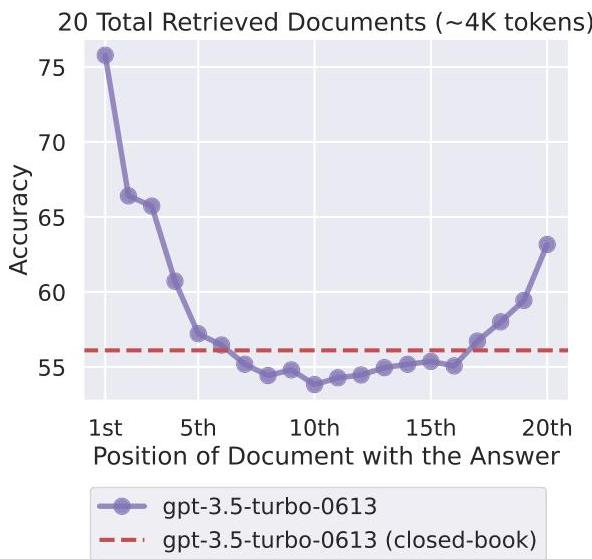
Figure 1: Changing the location of relevant information (in this case, the position of the passage that answers an input question) within the language model's input context results in a U-shaped performance curve—models are better at using relevant information that occurs at the very beginning (primacy bias) or end of its input context (recency bias), and performance degrades significantly when models must access and use information located in the middle of its input context.

relevant documents from a search engine, database query results, etc; Petroni et al., 2020; Ram et al., 2023; Shi et al., 2023; Mallen et al., 2023; Schick et al., 2023, inter alia).

Handling these use-cases requires language models to successfully operate over long sequences. Existing language models are generally implemented with Transformers (Vaswani et al., 2017), which require memory and compute that increases quadratically in sequence length. As a result, Transformer language models were often trained with relatively small context windows (between 512-2048 tokens). Recent improvements in hardware (e.g., faster GPUs with more memory) and algorithms (Dai et al., 2019; Dao et al., 2022; Poli et al.,

---

2023; Rubin and Berant, 2023, inter alia)* have resulted in language models with larger context windows (e.g., 4096, 32K, and even 100K tokens), but it remains unclear how these extended-context language models make use of their input contexts when performing downstream tasks.

We empirically investigate this question via controlled experiments with a variety of state-of-the-art open (MPT-30B-Instruct, LongChat-13B (16K)) and closed (OpenAI’s GPT-3.5-Turbo and Anthropic’s Claude-1.3) language models in settings that require accessing and using information within an input context. In particular, our experiments make controlled changes to the input context size and the position of the relevant information within the input context and study their effects on language model performance. If language models can robustly use information within long input contexts, then their performance should be *minimally affected* by the position of the relevant information in the input context.

We first experiment with multi-document question answering, which requires models to reason over provided documents to find relevant information and use it to answer a given question; this task mimics the retrieval-augmented generation setup underlying many commercial generative search and question answering applications (e.g., Bing Chat). In this setting, we control (i) the input context length by changing the number of documents in the input context (akin to retrieving more or less documents in retrieval-augmented generation), and (ii) control the position of the relevant information within the input context by changing the order of the documents to place the relevant document at the beginning, middle or end of the context.

We find that changing the position of relevant information in the input context can substantially affect model performance, indicating that current language models do not robustly access and use information in long input contexts. Furthermore, we observe a distinctive U-shaped performance curve (Figure 1); language model performance is highest when relevant information occurs at the very beginning (primacy bias) or end of its input context (recency bias), and performance significantly degrades when models must access and use information in the middle of their input context (§2.3). For example, when relevant information is placed in the middle of its input context, GPT-3.5-Turbo’s performance on the multi-document question task is lower than its performance when predicting *without any documents* (i.e., the closed-book setting; 56.1%). Furthermore, we find that models often have identical performance to their extended-context counterparts, indicating that extended-context models are not necessarily better at using their input context (§2.3).

Given that language models struggle to retrieve and use relevant information in the multi-document question answering task, to what extent can language models even *retrieve* from their input contexts? We study this question with a synthetic key-value retrieval task, which is designed to be a minimal testbed for the basic ability to retrieve matching tokens from the input context. In this task, models are given a collection of JSON-formatted key-value pairs and must return the value associated with a specific key. Similar to the multi-document QA task, the key-value retrieval task admits controlled changes to the input context length (adding more key-value pairs) and the position of relevant information. Although some models perform the synthetic key-value retrieval task perfectly, other models struggle to simply retrieve matching tokens that occur in the middle of their input context and continue to exhibit a U-shaped performance curve.

To better understand why language models struggle to robustly access and use information in their input contexts, we study the role of model architecture (decoder-only vs. encoder-decoder), query-aware contextualization, and instruction fine-tuning (§4). We find that:

- Encoder-decoder models are relatively robust to changes in the position of relevant information within their input context, but only when evaluated on sequences within its training-time sequence length. When evaluated on sequences longer than those seen during training, we observe a U-shaped performance curve (§4.1).
- Query-aware contextualization (placing the query before *and* after the documents or key-value pairs) enables near-perfect performance on the synthetic key-value task, but minimally changes trends in multi-document QA (§4.2).
- Even base language models (i.e., without instruction fine-tuning) show a U-shaped performance curve as we vary the position of relevant information in the input context.

Our results indicate that prompting language

---

models with longer input contexts is a trade-off—providing the language model with more information may help it perform the downstream task, but it also increases the amount of content that the model must reason over, potentially decreasing accuracy. To better understand this trade-off in practice, we perform a case study with retriever-reader models on open-domain question answering (§5). In contrast to our controlled multi-document QA task, where the context always contains exactly one document that answers the question, none or many of the top $k$ documents may contain the answer in the open-domain QA setting. When retrieving from Wikipedia to answer queries from NaturalQuestions-Open, we find that model performance saturates long before retriever recall saturates, indicating that current models fail to effectively use additional retrieved documents—using 50 documents instead of 20 retrieved documents only marginally improves performance ($\sim$1.5% for GPT-3.5-Turbo and $\sim$1% for claude-1.3).

Our analysis provides a better understanding of how language models use their input context and introduces new evaluation protocols for future long-context models; to claim that a language model can robustly use information within long input contexts, it is necessary to show that its performance is minimally affected by the position of the relevant information in the input context (e.g., minimal difference in best- and worst-case performance). To facilitate further work on understanding and improving how language models use their input context, we release our code and evaluation data.

## 2 Multi-Document Question Answering

Our goal is to better understand how language models use their input context. To this end, we analyze model performance on multi-document question answering, which requires models to find relevant information within an input context and use it to answer the question. In particular, we make controlled changes to the length of the input context and the position of the relevant information and measure changes in task performance.

### 2.1 Experimental Setup

In the multi-document question answering task, the model inputs are (i) a question to answer and (ii) $k$ documents (e.g., passages from Wikipedia), where exactly one of the documents contains the answer to the question and $k-1$ “distractor” documents do not. This task requires the model to access the document that contains the answer within its input context and use it to answer the question. Figure 2 presents an example.

We instantiate this task with data from NaturalQuestions-Open *(Lee et al., 2019; Kwiatkowski et al., 2019)*, which contains historical queries issued to the Google search engine, coupled with human-annotated answers extracted from Wikipedia. In particular, we take the 2655 queries where the annotated long answer is a paragraph (as opposed to a list or a table). We use passages (chunks of at most 100 tokens) from Wikipedia as documents within our input contexts. For each of the queries, we need a document that contains the answer and $k-1$ distractor documents that do not contain the answer. To obtain a document that answers the question, we use the Wikipedia paragraph that contains the answer from the NaturalQuestions annotations.

To collect $k-1$ distractor documents that do not contain the answer, we use a retrieval system *(Contriever, fine-tuned on MS-MARCO; Izacard et al., 2021)* to retrieve the $k-1$ Wikipedia chunks that are most relevant to the query and do not contain any of the NaturalQuestions-annotated answers. In the input context, the distractor documents are presented in order of decreasing relevance.

To modulate the position of relevant information within the input context, we adjust the order of the documents to change the position of the document that contains the answer (Figure 3). To modulate the input context length in this task, we increase or decrease the number of retrieved documents that do not contain the answer (Figure 4).

Following *Kandpal et al. (2022)* and *Mallen et al. (2023)*, we use accuracy as our primary evaluation metric, judging whether any of the correct answers (as taken from the NaturalQuestions annotations) appear in the predicted output.

---

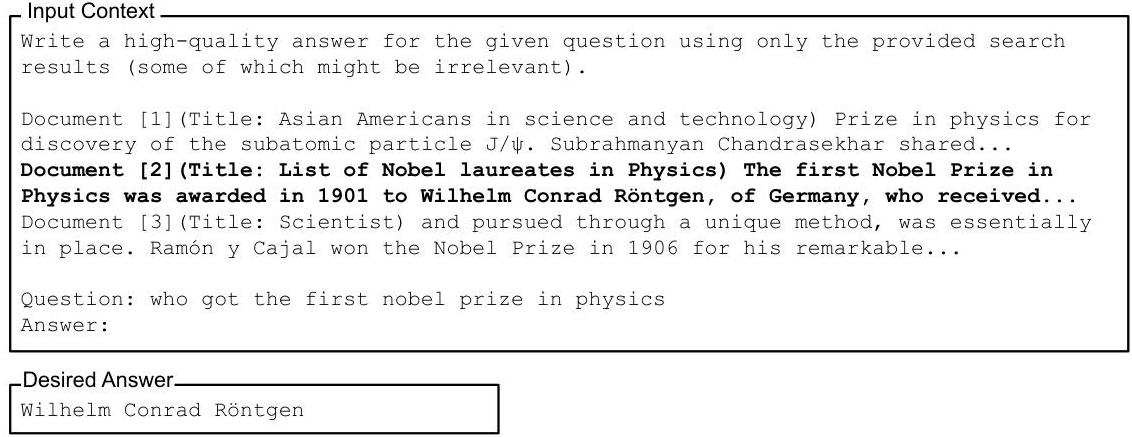
Figure 2: Example of the multi-document question answering task, with an input context and the desired model answer. The document containing the answer is bolded within the input context here for clarity.

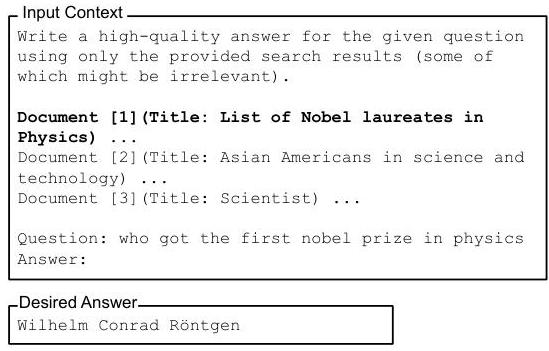
Figure 3: Modulating the position of relevant information within the input context for the multi-document question answering example presented in Figure 2. Reordering the documents in the input context does not affect the desired output.

Our experimental setup is similar to the needle-in-a-haystack experiments of Ivgi et al. (2023), who compare question answering performance when the relevant paragraph is placed (i) at the beginning of the input or (ii) a random position within the input. They find that encoder-decoder models have significantly higher performance when relevant information is placed at the start of the input context. In contrast, we study finer-grained changes in the position of relevant information.

# 2.2 Models

We analyze several state-of-the-art open and closed language models. We use greedy decoding when generating outputs and leave exploration of other decoding methods to future work. We use a standard set of prompts for each model (Figure 2).

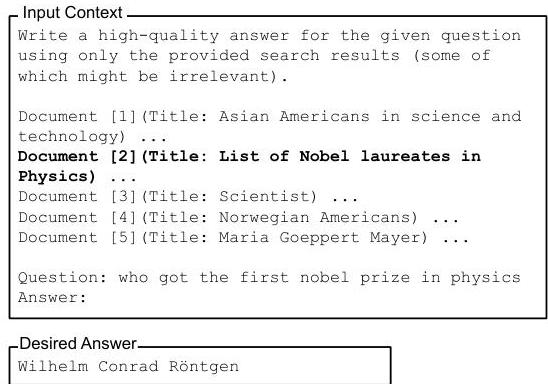
Figure 4: Modulating the input context length of the multi-document question answering example presented in Figure 2. Adding documents that do not contain the answer increases the length of the input context, but does not affect the desired output.

Open models. We experiment with MPT-30B-Instruct, which has a maximum context length of 8192 tokens. The model was initially pre-trained on 1 trillion tokens using 2048-token sequences, followed by an additional sequence length adaptation pre-training phase on 50 billion tokens using 8192-token sequences. MPT-30B-Instruct uses ALiBi (Press et al., 2022) to represent positional information. We also evaluate LongChat-13B (16K) (Li et al., 2023), which extends the LLaMA-13B (Touvron et al., 2023a) context window from 2048 to 16384 tokens by using condensed rotary positional embeddings before fine-tuning with 16384-token sequences.

Closed models. We use the OpenAI API to experiment with GPT-3.5-Turbo and GPT-3.5-Turbo

---

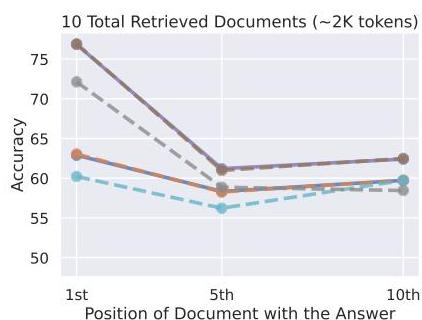
Figure 5: The effect of changing the position of relevant information (document containing the answer) on multi-document question answering performance. Lower positions are closer to the start of the input context. Performance is highest when relevant information occurs at the very start or end of the context, and rapidly degrades when models must reason over information in the middle of their input context.

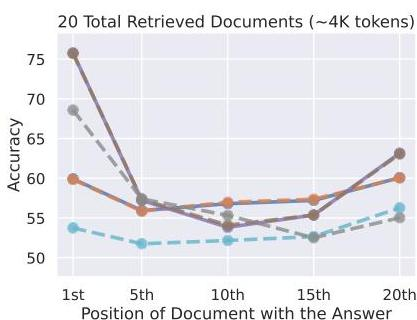

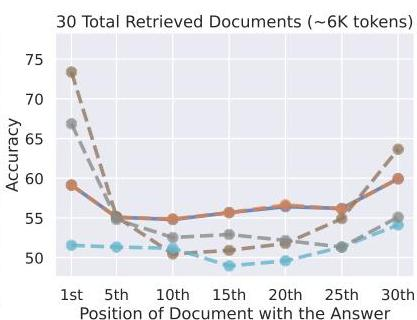

(16K).5 GPT-3.5-Turbo has a maximum context length of 4K tokens, and GPT-3.5-Turbo (16K) is a version with an extended maximum context length of 16K tokens. We evaluate Claude-1.3 and Claude-1.3 (100K) with the Anthropic API; Claude-1.3 has a maximum context length of 8K tokens, and Claude-1.3 (100K) has an extended context length of 100K tokens.6

# 2.3 Results and Discussion

We experiment with input contexts containing 10, 20, and 30 total documents. Figure 5 presents multi-document question answering performance when varying the position of relevant information within the input context. To contextualize model performance, we also evaluate on the closed-book and oracle settings (Table 1). In the closed-book setting, models are not given any documents in their input context, and must rely on their parametric memory to generate the correct answer. On the other hand, in the oracle setting, language models are given the single document that contains the answer and must use it to answer the question.

Model performance is highest when relevant information occurs at the beginning or end of its input context. As illustrated in Figure 5, changing the position of relevant information in the input context leads to substantial decreases in model performance. In particular, we see a distinctive U-

[tbl-0.html](tbl-0.html)

Table 1: Closed-book and oracle accuracy of language models on the multi-document question answering task.

shaped performance curve—models are often much better at using relevant information that occurs at the very beginning (primacy bias) and very end of contexts (recency bias), and suffer degraded performance when forced to use information within the middle of its input context. For example, GPT-3.5-Turbo's multi-document QA performance can drop by more than  $20\%$  in the worst case, performance in 20- and 30-document settings is lower than performance without any input documents (i.e., closed-book performance;  $56.1\%$ ). These results indicate that current models cannot effectively reason over their entire context window when prompted for downstream tasks.

Extended-context models are not necessarily better at using input context. When the input context fits in the context window of both a model and its extended-context counterpart, we see that performance between them is nearly identical. For example, the 10- and 20-document settings both fit in the context window of GPT-3.5-Turbo and GPT-3.5-Turbo (16K), and we observe that their performance as a function of position of relative information is nearly superimposed (solid purple and dashed brown series in Figure 5). These results

---

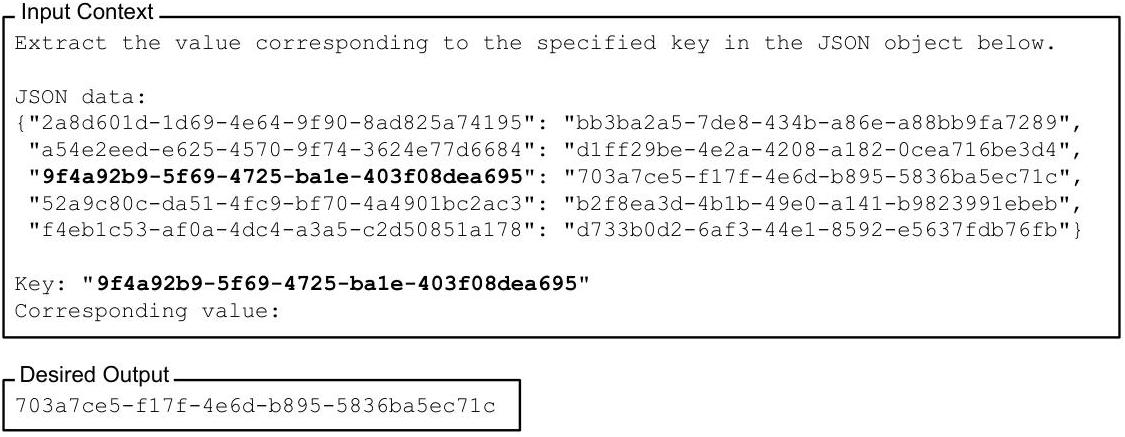
Figure 6: Example of the key-value retrieval task, with an input context and the desired model output. Given a key, the goal is to return the associated value. All keys and values are 128-bit UUIDs. The relevant key-value pair for answering the query is bolded here within the input context for clarity.

indicate that extended-context models are not necessarily better than their non-extended counterparts at using their input context.

# 3 How Well Can Language Models Retrieve From Input Contexts?

Given that language models struggle to retrieve and use information from the middle of their input contexts in the multi-document question answering task, to what extent can they simply retrieve from input contexts? We study this question with a synthetic key-value retrieval task, which is designed to provide a minimal testbed for the basic ability to retrieve matching tokens from an input context.

# 3.1 Experimental Setup

In our synthetic key-value retrieval task, the inputs are (i) a string-serialized JSON object with  $k$  key-value pairs, where each of the keys and values are unique, randomly-generated UUIDs and (ii) a key within the aforementioned JSON object. The goal is to return the value associated with the specified key. Thus, each JSON object contains one relevant key-value pair (where the value is to be returned), and  $k - 1$  irrelevant "distractor" key-value pairs. Figure 6 provides an example input context and its corresponding desired output. We again measure accuracy by evaluating whether the correct value appears in the predicted output.

Our synthetic key-value retrieval task shares similar goals with the Little Retrieval Test of Papailiopoulos et al. (2023) and the fine-grained line retrieval task of Li et al. (2023), but we explicitly seek to distill and simplify the task by removing as

much natural language semantics as possible (using random UUIDs instead), since language features may present potential confounders. For example, Transformer language models may have varying sensitivity to different linguistic features in their input (O'Connor and Andreas, 2021).

To modulate the position of relevant information within the input context, we change the position of the key to retrieve within the serialized JSON object. To modulate the input context length, we change the number of input JSON key-value pairs  $k$  by adding or removing random keys, changing the number of distractor key-value pairs.

# 3.2 Results and Discussion

We experiment with input contexts containing 75, 140, and 300 key-value pairs (500 examples each). We use the same set of models as the multi-document question answering experiments, see §2.2 for more details.

Figure 7 presents key-value retrieval performance. Claude-1.3 and Claude-1.3 (100K) do nearly perfectly on all evaluated input context lengths, but other models struggle, especially when contexts have 140 or 300 key-value pairs—although the synthetic key-value retrieval task only requires identifying exact match within the input context, not all models achieve high performance.

Similar to our multi-document QA results, GPT-3.5-Turbo, GPT-3.5-Turbo (16K), and MPT-30B-Instruct have the lowest performance when they must access key-value pairs in the middle of their input context. LongChat-13B (16K) exhibits a different trend in the 140 key-value setting; we qualitatively observe that when relevant information is

---

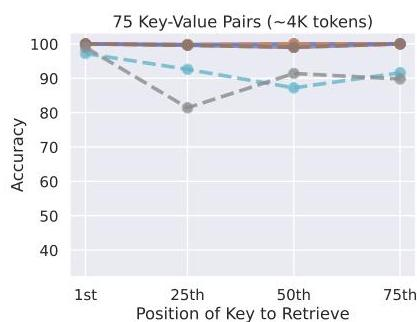
Figure 7: The effect of changing the input context length and the position of relevant information on key-value retrieval performance. Lower positions are closer to the start of the input context. Although some models show perfect accuracy on this synthetic task (e.g., Claude-1.3 and Claude-1.3 (100K)), we see again that performance is often highest when relevant information is occurs at the very start or end of the context, and rapidly degrades when models must retrieve from the middle of the input context.

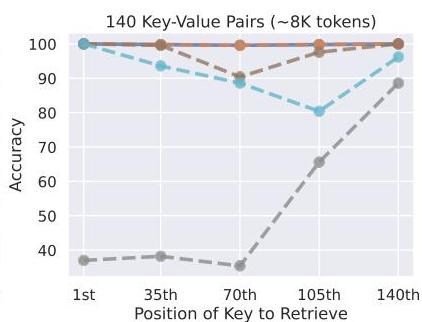

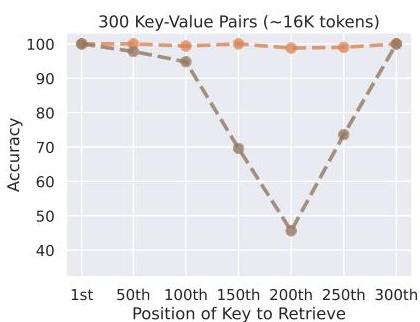

placed at the start of the input context, LongChat-13B (16K) tends to generate code to retrieve the key, rather than outputting the value directly.

# 4 Why Are Language Models Not Robust to Changes in the Position of Relevant Information?

Our multi-document question answering and key-value retrieval results show that language models struggle to robustly access and use information in long input contexts, since performance degrades significantly when changing the position of relevant information. To better understand why, we perform some preliminary investigations into the role of model architecture (decoder-only vs. encoder-decoder), query-aware contextualization, and instruction fine-tuning.

# 4.1 Effect of Model Architecture

The open models we evaluated are all decoder-only models—at each timestep, they may only attend to prior tokens. To better understand the potential effects of model architecture on how language model use context, we compare decoder-only and encoder-decoder language models.

We experiment with Flan-T5-XXL (Raffel et al., 2020; Chung et al., 2022) and Flan-UL2 (Tay et al., 2023). Flan-T5-XXL is trained with a sequences of 512 tokens (encoder and decoder). Flan-UL2 is initially trained with sequences of 512 tokens (encoder and decoder), but is then pre-trained for an extra 100K steps with 1024 tokens (encoder and decoder) before instruction fine-tuning on sequences with 2048 tokens in the encoder and 512 tokens in the decoder. However, since these models use

relative positional embeddings, they can (in principle) extrapolate beyond these maximum context lengths; Shaham et al. (2023) find that both models can perform well with sequences of up to 8K tokens.

Figure 8 compares the performance of decoder-only and encoder-decoder models. When Flan-UL2 is evaluated on sequences within its 2048-token training-time context window (Figure 8; left subplot), its performance is relatively robust to changes in the position of relevant information within the input context (1.9% absolute difference between best- and worst-case performance). When evaluated on settings with sequences longer than 2048 tokens (Figure 8; center and right), Flan-UL2 performance begins to degrade when relevant information is placed in the middle. Flan-T5-XXL shows a similar trend, where longer input contexts result in a greater performance degradation when placing relevant information in the middle of the input context. We hypothesize that encoder-decoder models may make better use of their context windows because their bidirectional encoder allows processing each document in the context of future documents, potentially improving relative importance estimation between documents.

# 4.2 Effect of Query-Aware Contextualization

Our multi-document QA and key-value retrieval experiments place the query (i.e., question to answer or key to retrieve) after the data to process (i.e., the documents or the key-value pairs). As a result, decoder-only models cannot attend to query tokens when contextualizing documents or key-value pairs, since the query only appears at the end

---

Figure 8: When encoder-decoder models (Flan-UL2 and Flan-T5-XXL) evaluated on sequences that are shorter than their encoder's training-time maximum sequence length (2048 and 512 tokens, respectively), they are relatively robust to changes in the position of relevant information within their input context (left subplot). In contrast, when these models are evaluated on sequences longer than those seen during training (center and right subplots), we observe a U-shaped performance curve—performance is higher when relevant information occurs at the beginning or end of the input context, as opposed to the middle of the input context.
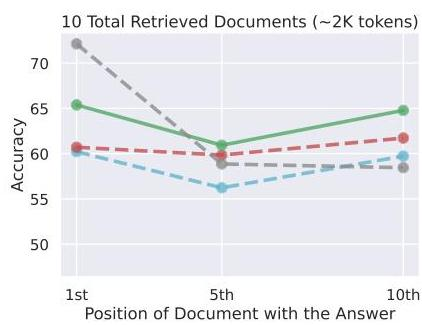
mpt-30b-instruct longchat-13b-16k flan-t5-xxl flan-ul2

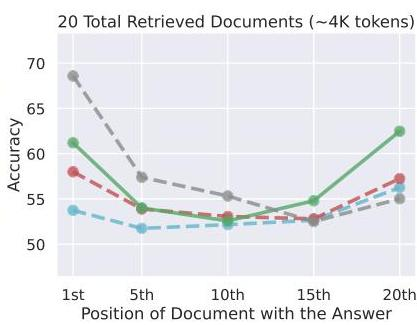

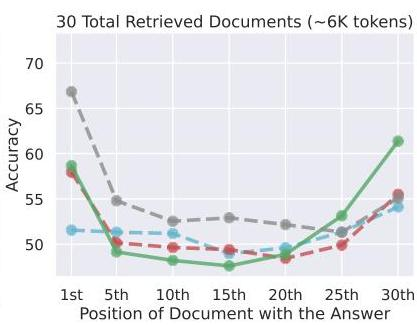

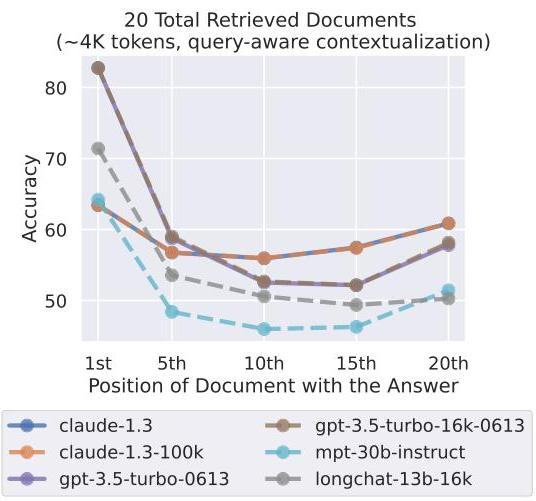
Figure 9: Query-aware contextualization (placing the query before and after the documents) does not substantially improve robustness of language models to changing the position of relevant information in multi-document QA; performance slightly increases when relevant information occurs at the very beginning, but otherwise slightly decreases.

of the prompt and decoder-only models can only attend to prior tokens at each timestep. In contrast, encoder-decoder models (which seem more robust to changes in the position of relevant information; §4.1) use a bidirectional encoder to contextualize input contexts—can we use this observation to improve decoder-only models by placing the query before and after the data, enabling query-aware contextualization of documents (or key-value pairs)?

We find that query-aware contextualization dramatically improves performance on the key-value retrieval task—all models achieve near-perfect per

formance on the 75, 140, and 300 key-value pair settings. For example, GPT-3.5-Turbo (16K) with query-aware contextualization achieves perfect performance when evaluated with 300 key-value pairs.

In contrast, without query-aware contextualization, the worst-case performance is  $45.6\%$  (Figure 7). Despite the significant impact on key-value retrieval performance, query-aware contextualization minimally affects performance trends in the multi-document question answering task (Figure 9); it slightly improves performance when the relevant information is located at the very beginning of the input context, but slightly decreases performance in other settings.

# 4.3 Effect of Instruction Fine-Tuning

The models we evaluated are all instruction finetuned—after their initial pre-training, they undergo supervised fine-tuning on a dataset of instructions and responses. The task specification and/or instruction is commonly placed at the beginning of the input context in supervised instruction finetuning data, which might lead instruction finetuned language models to place more weight on the start of the input context. To better understand the potential effects of instruction fine-tuning on how language models use long input contexts, we compare the multi-document question answering performance of MPT-30B-Instruct against its base model (i.e., before instruction fine-tuning) MPT-30B. We use the same experimental setup as §2.

Figure 10 compares the multi-document QA performance of MPT-30B and MPT-30B-Instruct as a function of the position of the relevant in

---

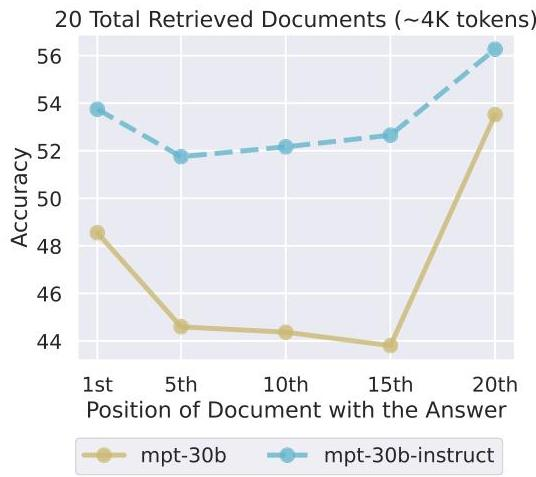
Figure 10: Multi-document QA performance of MPT-30B-Instruct compared against its base model (i.e., before instruction fine-tuning) MPT-30B. Both models have a U-shaped performance curve, where performance is much higher when relevant information occurs at the start or end of the input context, indicating that the instruction fine-tuning process itself is not necessarily responsible for these performance trends.

formation in the input context. Surprisingly, we see that both MPT-30B and MPT-30B-Instruct exhibit a U-shaped performance curve, where performance is highest when relevant information occurs at the very beginning or very end of the context. Although the absolute performance of MPT-30B-Instruct is uniformly higher than that of MPT-30B, their overall performance trends are similar. We also observe that instruction fine-tuning slightly reduces the worst-case performance disparity from nearly  $10\%$  between the base model best- and worst-case performance to around  $4\%$ .

These observations complement prior work, which found that non-instruction fine-tuned language models are biased towards recent tokens (i.e., the end of the input context; Khandelwal et al., 2018; Press et al., 2021). This recency bias has been observed in past work when evaluating models on next-word prediction of contiguous text, a setting where language models minimally benefit from long-range information (Sun et al., 2021). In contrast, our results show that language models are capable of using longer-range information (i.e., the beginning of the input context) when prompted with instruction-formatted data. We hypothesize that non-instruction fine-tuned language models learn to use these long contexts from similarly-formatted data that may occur in Internet text seen during pre-training, e.g., StackOverflow questions

and answers.

To better understand the effect of additional fine-tuning and model scale, we also experimented with Llama-2 models of varying sizes (7B, 13B, and 70B) with and without additional supervised fine-tuning and reinforcement learning from human feedback (Appendix E). We find that the U-shaped performance curve only appears in sufficiently large language models (with or without additional fine-tuning)—the 7B Llama-2 models are solely recency biased, while the 13B and 70B models exhibit a U-shaped performance curve. In addition, we see that the Llama-2 supervised fine-tuning and reinforcement learning from human feedback procedure slightly mitigates the positional bias in smaller models (13B, akin to trends shown when comparing MPT-30B and MPT-30B-Instruct), but minimally affects trends on larger models (70B).

# 5 Is More Context Is Always Better? A Case Study With Open-Domain QA

Our results indicate that prompting language models with longer input contexts is a trade-off—providing the language model with more information may help it perform the downstream task, but it also increases the amount of content that the model must reason over, potentially decreasing accuracy. Even if a language model can take in 16K tokens, is it actually beneficial to provide 16K tokens of context? The answer to this question is ultimately downstream task-specific since it depends on the marginal value of the added context and the model's ability to effectively use long input contexts, but we perform a case study with open-domain question answering on NaturalQuestions-Open to better understand this trade-off in existing language models.

We use language models in a standard retriever-reader setup. A retrieval system (Contriever, finetuned on MS-MARCO) takes an input query from NaturalQuestions-Open and returns the  $k$  documents from Wikipedia with the highest relevance score. To condition language models on these retrieved documents, we simply include them in the prompt. We evaluate retriever recall and reader accuracy (whether any of the annotated answers appear in the predicted output) as a function of the number of retrieved documents  $k$ . We use a subset of NaturalQuestions-Open where the long answer is a paragraph (as opposed to a table or a list).

Figure 11 presents retriever recall and open-

---

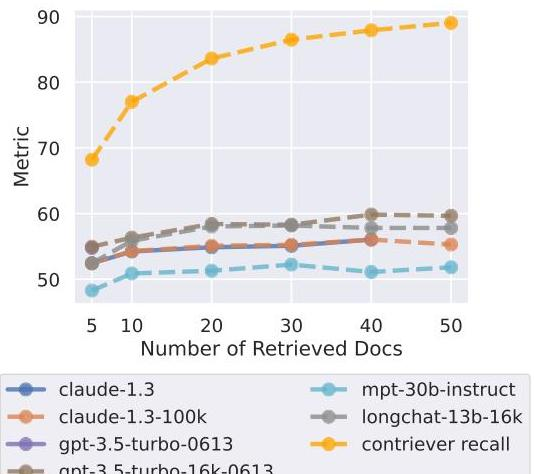
Figure 11: Retriever recall and model performance as a function of the number of retrieved documents. Model performance saturates long before retriever recall, indicating that the models have difficulty making use of the extra retrieved documents.

domain QA results. We see that reader model performance saturates long before retriever performance saturates, indicating that readers are not effectively using the extra context. Using more than 20 retrieved documents only marginally improves reader performance ( $\sim 1.5\%$  for GPT-3.5-Turbo and  $\sim 1\%$  for Claude-1.3), while significantly increasing the input context length (and thus latency and cost). These results, coupled with the observation that models are often better at retrieving and using information at the start or end of the input contexts, suggest that effective reranking of retrieved documents (pushing relevant information closer to the start of the input context) or ranked list truncation (retrieving fewer documents when appropriate; Arampatzis et al., 2009) may be promising directions for improving how language-model-based readers use retrieved context.

# 6 Related Work

# 6.1 Long-Context Language Models

There is much prior work in designing performant language models with cheaper scaling than Transformers in the context length. Many lines of work pursue Transformer variants with attention modifications like recurrence (Dai et al., 2019), factorizing attention into computationally less intensive approximations (Beltagy et al., 2020; Zaheer et al., 2020), or low-rank approximations (Wang et al., 2020; Peng et al., 2021). Dao et al. (2022) instead provide a faster exact attention by a carefully

crafted IO-aware CUDA kernel. Separately, there are attempts to do away with attention entirely to remove quadratic sequence length complexity, often through convolution and/or linear RNNs, e.g., in RWKV (Peng, 2023), S4 (Gu et al., 2022), or Hyena (Poli et al., 2023). Many prior efforts evaluate perplexity on a diverse web corpus as a proxy for the ability to process long contexts; this work shows that precise knowledge access on long contexts may be an added challenge.

# 6.2 How Do Language Models Use Context?

The pioneering work of Khandelwal et al. (2018) showed that small LSTM language models make increasingly coarse use of longer-term context; Sankar et al. (2019) found similar results in dialogue models. In a similar vein, Daniluk et al. (2017) find that attentive LSTM language models tend to mainly use recent history. Petroni et al. (2020) were among the first to demonstrate the potential of combining context from an information retrieval system with a pretrained language models for unsupervised question answering. O'Connor and Andreas (2021) found that many information-destroying operations had marginal effects on Transformer LMs' predictions. Krishna et al. (2022) found that long-context neural generation in modestly-sized Transformer language models degenerates because models fail to properly condition on long context. Finally, studying long-context models, Sun et al. (2021) found that longer contexts improves prediction of only a few tokens, an empirical finding consistent with the theory of Sharan et al. (2018), who showed that sequence distributions with bounded mutual information necessarily lead to marginal average prediction benefits from increasingly long context. Qin et al. (2023) analyze how efficient Transformers perform on a variety of long-context downstream NLP tasks, finding that long-context transformers are recency-biased and do not effectively use long-range context.

# 6.3 The Serial-Position Effect

The U-shaped curve we observe in this work has a connection in psychology known as the serial-position effect (Ebbinghaus, 1913; Murdock Jr, 1962), that states that in free-association recall of elements from a list, humans tend to best remember the first and last elements of the list. The serial-position effect plays a role in understanding how humans develop short- and long-term mem

---

ory. Observing a serial-position-like effect in language models is perhaps surprising, since the self-attention mechanisms underlying Transformer language models is technically equally capable of retrieving any token from their contexts.

## 7 Conclusion

We empirically study how language models use long input contexts via a series of controlled experiments. We show that language model performance degrades significantly when changing the position of relevant information, indicating that models struggle to robustly access and use information in long input contexts. In particular, performance is often lowest when models must use information in the middle of long input contexts. We conduct a preliminary investigation of the role of (i) model architecture, (ii) query-aware contextualization, and (iii) instruction fine-tuning to better understand how they affect how language models use context. Finally, we conclude with a practical case study of open-domain question answering, finding that the performance of language model readers saturates far before retriever recall. Our results and analysis provide a better understanding of how language models use their input context and provides new evaluation protocols for future long-context models.

## Acknowledgments

We would like to thank Luke Zettlemoyer, who served as our TACL action editor, and the the anonymous reviewers for their comments and feedback. We also thank Claudiu Leoveanu-Condrei, Megan Leszczynski, Dmytro Okhonko, Maithra Raghu, Eric Wallace and Sang Michael Xie for feedback and discussions that helped improve this work. Further, we are grateful to Sewon Min for her help with the AmbigQA dataset. This work was supported by the Stanford Center for Research on Foundation Models (CRFM), by OpenAI via an API credits grant to the Stanford CRFM, and by Anthropic via the Claude academic access program.

## References

- Arampatzis et al. (2009) Avi Arampatzis, Jaap Kamps, and Stephen Robertson. 2009. Where to stop reading a ranked list? threshold optimization using truncated score distributions. In Proc. of SIGIR.
- Beltagy et al. (2020) Iz Beltagy, Matthew E. Peters, and Arman Cohan. 2020. Longformer: The long-document transformer. ArXiv:2004.05150.
- Won Chung et al. (2022) Hyung Won Chung, Le Hou, Shayne Longpre, Barret Zoph, Yi Tay, William Fedus, Yunxuan Li, Xuezhi Wang, Mostafa Dehghani, Siddhartha Brahma, Albert Webson, Shixiang Shane Gu, Zhuyun Dai, Mirac Suzgun, Xinyun Chen, Aakanksha Chowdhery, Alex Castro-Ros, Marie Pellat, Kevin Robinson, Dasha Valter, Sharan Narang, Gaurav Mishra, Adams Yu, Vincent Zhao, Yanping Huang, Andrew Dai, Hongkun Yu, Slav Petrov, Ed H. Chi, Jeff Dean, Jacob Devlin, Adam Roberts, Denny Zhou, Quoc V. Le, and Jason Wei. 2022. Scaling instruction-finetuned language models. ArXiv:2210.11416.
- Dai et al. (2019) Zihang Dai, Zhilin Yang, Yiming Yang, Jaime Carbonell, Quoc Le, and Ruslan Salakhutdinov. 2019. Transformer-XL: Attentive language models beyond a fixed-length context. In Proc. of ACL.
- Daniluk et al. (2017) Michał Daniluk, Tim Rocktäschel, Johannes Welbl, and Sebastian Riedel. 2017. Frustratingly short attention spans in neural language modeling. In Proc. of ICLR.
- Dao et al. (2022) Tri Dao, Daniel Y. Fu, Stefano Ermon, Atri Rudra, and Christopher Ré. 2022. FlashAttention: Fast and memory-efficient exact attention with IO-awareness. ArXiv:2205.14135.
- Ebbinghaus (1913) Hermann Ebbinghaus. 1913. Memory: A contribution to experimental psychology. H. A. Ruger & C. E. Bussenius, Trans.
- Gu et al. (2022) Albert Gu, Karan Goel, and Christopher Ré. 2022. Efficiently modeling long sequences with structured state spaces. In Proc. of ICLR.
- Jvgi et al. (2023) Maor Ivgi, Uri Shaham, and Jonathan Berant. 2023. Efficient long-text understanding with short-text models. Transactions of the Association for Computational Linguistics, 11:284–299.
- Izacard et al. (2021) Gautier Izacard, Mathilde Caron, Lucas Hosseini, Sebastian Riedel, Piotr Bojanowski, Armand Joulin, and Edouard Grave. 2021. Unsupervised dense information retrieval with contrastive learning. ArXiv:2112.09118.
- Izacard and Grave (2021) Gautier Izacard and Edouard Grave. 2021. Leveraging passage retrieval with generative models

---

for open domain question answering. In Proc. of EACL.
- (6) Nikhil Kandpal, Haikang Deng, Adam Roberts, Eric Wallace, and Colin Raffel. 2022. Large language models struggle to learn long-tail knowledge. ArXiv:2211.08411.
- (7) Urvashi Khandelwal, He He, Peng Qi, and Dan Jurafsky. 2018. Sharp nearby, fuzzy far away: How neural language models use context. In Proc. of ACL.
- (8) Kalpesh Krishna, Yapei Chang, John Wieting, and Mohit Iyyer. 2022. RankGen: Improving text generation with large ranking models. In Proc. of EMNLP.
- (9) Tom Kwiatkowski, Jennimaria Palomaki, Olivia Redfield, Michael Collins, Ankur Parikh, Chris Alberti, Danielle Epstein, Illia Polosukhin, Jacob Devlin, Kenton Lee, Kristina Toutanova, Llion Jones, Matthew Kelcey, Ming-Wei Chang, Andrew M. Dai, Jakob Uszkoreit, Quoc Le, and Slav Petrov. 2019. Natural Questions: A benchmark for question answering research. Transactions of the Association for Computational Linguistics, 7:452–466.
- (10) Kenton Lee, Ming-Wei Chang, and Kristina Toutanova. 2019. Latent retrieval for weakly supervised open domain question answering. In Proc. of ACL.
- (11) Mina Lee, Percy Liang, and Qian Yang. 2022. CoAuthor: Designing a human-AI collaborative writing dataset for exploring language model capabilities. In Proc. of CHI.
- (12) Dacheng Li, Rulin Shao, Anze Xie, Ying Sheng, Lianmin Zheng, Joseph E. Gonzalez, Ion Stoica, Xuezhe Ma, , and Hao Zhang. 2023. How long can open-source LLMs truly promise on context length?
- (13) Alex Mallen, Akari Asai, Victor Zhong, Rajarshi Das, Daniel Khashabi, and Hannaneh Hajishirzi. 2023. When not to trust language models: Investigating effectiveness of parametric and non-parametric memories. In Proc. of ACL.
- (14) Sewon Min, Julian Michael, Hannaneh Hajishirzi, and Luke Zettlemoyer. 2020. AmbigQA: Answering ambiguous open-domain questions. In Proc. of EMNLP.
- (15) Bennet B. Murdock Jr. 1962. The serial position effect of free recall. Journal of experimental psychology, 64(5):482.
- (16) Joe O’Connor and Jacob Andreas. 2021. What context features can Transformer language models use? In Proc. of ACL.
- (17) Dimitris Papailiopoulos, Kangwook Lee, and Jyyong Sohn. 2023. A little retrieval test for large language models. https://github.com/anadim/the-little-retrieval-test.
- (18) Bo Peng. 2023. RWKV-LM. https://github.com/BlinkDL/RWKV-LM.
- (19) Hao Peng, Nikolaos Pappas, Dani Yogatama, Roy Schwartz, Noah Smith, and Lingpeng Kong. 2021. Random feature attention. In Proc. of ICLR.
- (20) Fabio Petroni, Patrick Lewis, Aleksandra Piktus, Tim Rocktäschel, Yuxiang Wu, Alexander H Miller, and Sebastian Riedel. 2020. How context affects language models’ factual predictions. In Proc. of AKBC.
- (21) Michael Poli, Stefano Massaroli, Eric Nguyen, Daniel Y. Fu, Tri Dao, Stephen Baccus, Yoshua Bengio, Stefano Ermon, and Christopher Ré. 2023. Hyena hierarchy: Towards larger convolutional language models. In Proc. of ICML.
- (22) Ofir Press, Noah A. Smith, and Mike Lewis. 2021. Shortformer: Better language modeling using shorter inputs. In Proc. of ACL.
- (23) Ofir Press, Noah A. Smith, and Mike Lewis. 2022. Train short, test long: Attention with linear biases enables input length extrapolation. In Proc. of ICLR.
- (24) Guanghui Qin, Yukun Feng, and Benjamin Van Durme. 2023. The NLP task effectiveness of long-range transformers. In Proc. of EACL.
- (25) Colin Raffel, Noam Shazeer, Adam Roberts, Katherine Lee, Sharan Narang, Michael Matena, Yanqi Zhou, Wei Li, and Peter J. Liu. 2020. Exploring the limits of transfer learning with a unified text-to-text Transformer. Journal of Machine Learning Research, 21(140):1–67.

---

Ori Ram, Yoav Levine, Itay Dalmedigos, Dor Muhlgay, Amnon Shashua, Kevin Leyton-Brown, and Yoav Shoham. 2023. In-context retrieval-augmented language models. ArXiv:2302.00083.

Ohad Rubin and Jonathan Berant. 2023. Long-range language modeling with self-retrieval. ArXiv:2306.13421.

Chinnadhurai Sankar, Sandeep Subramanian, Chris Pal, Sarath Chandar, and Yoshua Bengio. 2019. Do neural dialog systems use the conversation history effectively? an empirical study. In Proc. of ACL.

Timo Schick, Jane Dwivedi-Yu, Roberto Dessì, Roberta Raileanu, Maria Lomeli, Luke Zettlemoyer, Nicola Cancedda, and Thomas Scialom. 2023. Toolformer: Language models can teach themselves to use tools.

Uri Shaham, Maor Ivgi, Avia Efrat, Jonathan Berant, and Omer Levy. 2023. ZeroSCROLLS: A zero-shot benchmark for long text understanding. ArXiv:2305.14196.

Vatsal Sharan, Sham Kakade, Percy Liang, and Gregory Valiant. 2018. Prediction with a short memory. In Proc. of STOC.

Weijia Shi, Sewon Min, Michihiro Yasunaga, Minjoon Seo, Rich James, Mike Lewis, Luke Zettlemoyer, and Wen tau Yih. 2023. REPLUG: Retrieval-augmented black-box language models. ArXiv:2301.12652.

Kurt Shuster, Jing Xu, Mojtaba Komeili, Da Ju, Eric Michael Smith, Stephen Roller, Megan Ung, Moya Chen, Kushal Arora, Joshua Lane, Morteza Behrooz, William Ngan, Spencer Poff, Naman Goyal, Arthur Szlam, Y-Lan Boureau, Melanie Kambadur, and Jason Weston. 2022. BlenderBot 3: a deployed conversational agent that continually learns to responsibly engage. ArXiv:2208.03188.

Simeng Sun, Kalpesh Krishna, Andrew Mattarella-Micke, and Mohit Iyyer. 2021. Do long-range language models actually use long-range context? In Proc. of EMNLP.

Yi Tay, Mostafa Dehghani, Vinh Q. Tran, Xavier Garcia, Jason Wei, Xuezhi Wang, Hyung Won Chung, Siamak Shakeri, Dara Bahri, Tal Schuster, Huaixiu Steven Zheng, Denny Zhou, Neil Houlsby, and Donald Metzler. 2023. UL2: Unifying language learning paradigms. ArXiv:2205.05131.

Romal Thoppilan, Daniel De Freitas, Jamie Hall, Noam Shazeer, Apoorv Kulshreshtha, Heng-Tze Cheng, Alicia Jin, Taylor Bos, Leslie Baker, Yu Du, YaGuang Li, Hongrae Lee, Huaixiu Steven Zheng, Amin Ghafouri, Marcelo Menegali, Yanping Huang, Maxim Krikun, Dmitry Lepikhin, James Qin, Dehao Chen, Yuanzhong Xu, Zhifeng Chen, Adam Roberts, Maarten Bosma, Vincent Zhao, Yanqi Zhou, Chung-Ching Chang, Igor Krivokon, Will Rusch, Marc Pickett, Pranesh Srinivasan, Laichee Man, Kathleen Meier-Hellstern, Meredith Ringel Morris, Tulsee Doshi, Renelito Delos Santos, Toju Duke, Johnny Soraker, Ben Zevenbergen, Vinodkumar Prabhakaran, Mark Diaz, Ben Hutchinson, Kristen Olson, Alejandra Molina, Erin Hoffman-John, Josh Lee, Lora Aroyo, Ravi Rajakumar, Alena Butryna, Matthew Lamm, Viktoriya Kuzmina, Joe Fenton, Aaron Cohen, Rachel Bernstein, Ray Kurzweil, Blaise Aguera-Arcas, Claire Cui, Marian Croak, Ed Chi, and Quoc Le. 2022. LaMDA: Language models for dialog applications. ArXiv:2201.08239.

Hugo Touvron, Thibaut Lavril, Gautier Izacard, Xavier Martinet, Marie-Anne Lachaux, Timothée Lacroix, Baptiste Rozière, Naman Goyal, Eric Hambro, Faisal Azhar, Aurelien Rodriguez, Armand Joulin, Edouard Grave, and Guillaume Lample. 2023a. LLaMA: Open and efficient foundation language models. ArXiv:2302.13971.

Hugo Touvron, Louis Martin, Kevin Stone, Peter Albert, Amjad Almahairi, Yasmine Babaei, Nikolay Bashlykov, Soumya Batra, Prajjwal Bhargava, Shruti Bhosale, Dan Bikel, Lukas Blecher, Cristian Canton Ferrer, Moya Chen, Guillem Cucurull, David Esiobu, Jude Fernandes, Jeremy Fu, Wenyin Fu, Brian Fuller, Cynthia Gao, Vedanuj Goswami, Naman Goyal, Anthony Hartshorn, Saghar Hosseini, Rui Hou, Hakan Inan, Marcin Kardas, Viktor Kerkez, Madian Khabsa, Isabel Kloumann, Artem Korenev, Punit Singh Koura, Marie-Anne Lachaux, Thibaut Lavril, Jenya Lee, Diana Liskovich, Yinghai Lu, Yuning Mao, Xavier Martinet, Todor Mihaylov, Pushkar Mishra, Igor Molybog, Yixin

---

Nie, Andrew Poulton, Jeremy Reizenstein, Rashi Rungta, Kalyan Saladi, Alan Schelten, Ruan Silva, Eric Michael Smith, Ranjan Subramanian, Xiaqing Ellen Tan, Binh Tang, Ross Taylor, Adina Williams, Jian Xiang Kuan, Puxin Xu, Zheng Yan, Iliyan Zarov, Yuchen Zhang, Angela Fan, Melanie Kambadur, Sharan Narang, Aurelien Rodriguez, Robert Stojnic, Sergey Edunov, and Thomas Scialom. 2023b. Llama 2: Open foundation and fine-tuned chat models. ArXiv:2307.09288.

Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Lukasz Kaiser, and Illia Polosukhin. 2017. Attention is all you need. In Proc. of NeurIPS.

Sinong Wang, Belinda Z. Li, Madian Khabsa, Han Fang, and Hao Ma. 2020. Linformer: Self-attention with linear complexity. ArXiv:2006.04768.

Manzil Zaheer, Guru Guruganesh, Kumar Avinava Dubey, Joshua Ainslie, Chris Alberti, Santiago Ontanon, Philip Pham, Anirudh Ravula, Qifan Wang, Li Yang, and Amr Ahmed. 2020. Big Bird: Transformers for longer sequences. In Proc. of NeurIPS.

# A Ambiguity in Multi-Document QA Distractor Documents

Following past work on NaturalQuestions-Open (Izacard et al., 2021; Izacard and Grave, 2021, inter alia), we use a Wikipedia dump from late 2018 as our retrieval corpus. However, this standard Wikipedia dump has a small amount of temporal mismatch with the NaturalQuestions annotations.

For example, consider the question "what nfl team does robert griffin iii play for". The NaturalQuestions annotated answer is "currently a free agent". However, the Wikipedia retrieval corpus contains the information that he plays for the "Baltimore Ravens", since he was released from the team between the Wikipedia dump's timestamp and the NaturalQuestions annotation process.

We use the ambiguity annotations of Min et al. (2020) to create a subset unambiguous questions. Experiments on this unambiguous subset of the data show similar results and conclusions as the experiments on the full questions collection (Figure 12).

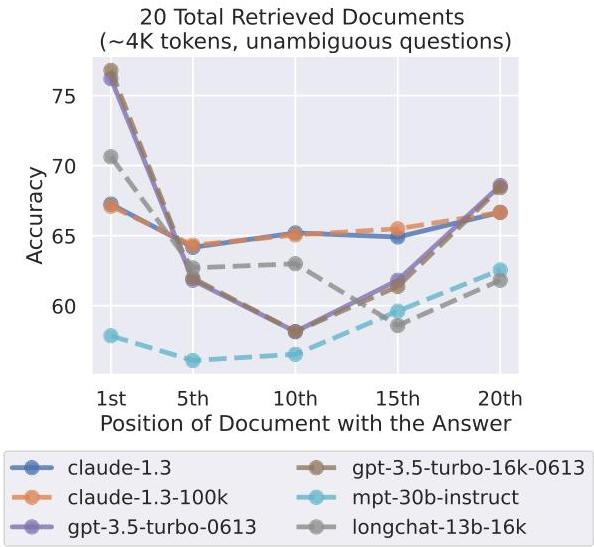
Figure 12: Language model performance on a unambiguous subset of questions.

# B Random Distractors in Multi-Document QA

We also run multi-document question answering experiments with random Wikipedia documents as distractors, which allows us to ablate the impact of retrieved distractors (hard negatives). Note that in this setting, the document containing the answer can often be identified with simple heuristics (e.g., lexical overlap with the query). Figure 13 presents the results of this experiment. Although all models have higher absolute accuracy in this setting, they surprisingly still struggle to reason over their entire input context, indicating that their performance degradation is not solely due to an inability to identify relevant documents.

# C Randomizing Distractor Order in Multi-Document QA

Our prompt instructs the language model to use the provided search results to answer the question. There may be a prior in the pre-training or instruction fine-tuning data to treat search results as sorted by decreasing relevance (i.e., the documents near the beginning of the input context are more likely to be useful than those at the end). To validate that our conclusions are not simply a byproduct of this bias, we run experiments with the modified instruction "Write a high-quality answer for the given question using only the provided search results (some of which might be irrelevant). The search results are ordered randomly." In addition, we randomly shuffle the  $k - 1$  distractor documents.

---

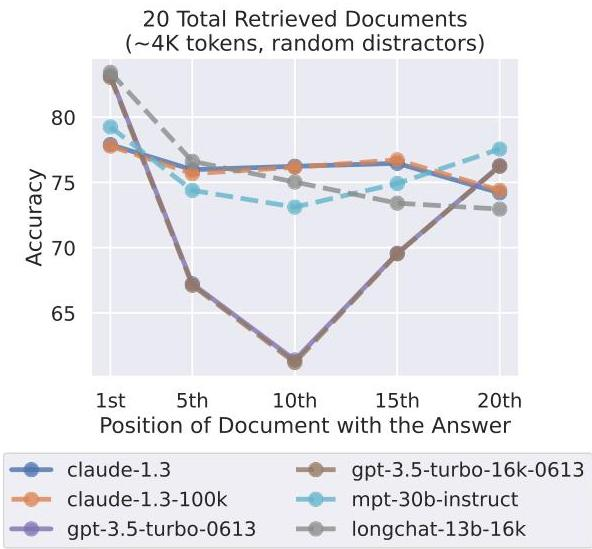
Figure 13: Language model performance on multi-document QA when using random distractors, rather than retrieved distractors.

Figure 14 presents the results of this experiment. We continue to see a U-shaped performance curve, with performance degrading when language models must use information in the middle of their input contexts. Comparing the results in §2.3 with those when randomizing the distractor order and mentioning such in the prompt, we see that randomization slightly decreases performance when the relevant information is at the very beginning of the context, and slightly increases performance when using information in the middle and end of the context.

# D GPT-4 Performance

We evaluate GPT-4 (8K) on a subset of 500 random multi-document QA examples with 20 total documents in each input context (Figure 15). GPT-4 achieves higher absolute performance than any other language model, but still shows a U-shaped performance curve—its performance is highest when relevant information occurs at the very start or end of the context, and performance degrades when it must use information in the middle of its input context.

# E Llama-2 Performance

We evaluate Llama-2 (Touvron et al., 2023b) on multi-document QA with 20 total documents in each input context. The Llama tokenizer produces longer sequences than the tokenizers for our previously-studied models, so we discard 20 exam

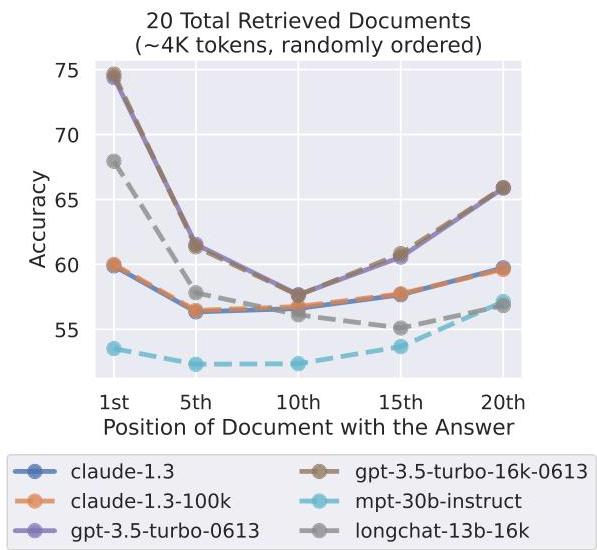
Figure 14: Language model performance when randomizing the order of the distractors (rather than presenting them in order of decreasing relevance) and mentioning as such in the prompt.

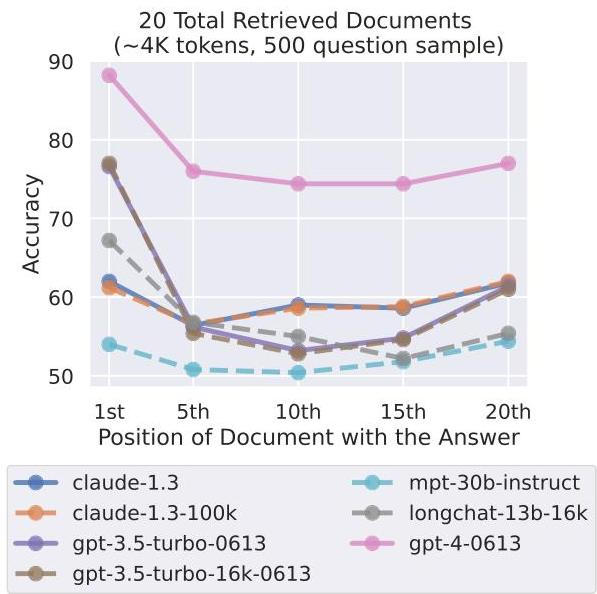
Figure 15: Although GPT-4 has higher absolute performance than other models, its performance still degrades when relevant information occurs in the middle of the input context.

---

plies (out of 2655) that exceed Llama-2's maximum context length of 4096 tokens. We experiment with models of varying sizes (7B, 13B, and 70B parameters), with and without additional supervised fine-tuning and reinforcement learning from human feedback ("-chat-" models). The results are presented in Figure 16.

Comparing Llama-2 models of varying sizes, we find that only the larger models (13B and 70B) exhibit the U-shaped performance curve (i.e., both primacy and recency bias)—the smallest Llama-2 models (7B) are solely recency-biased. Given these results, we hypothesize that prior work (e.g., Khandelwal et al., 2018; Sun et al., 2021) did not previously observe any primacy bias in language models because the models they studied were too small (less than 1B parameters).

Comparing between Llama-2 models with and without additional supervised fine-tuning and reinforcement learning from human feedback, we see that additional fine-tuning dramatically improves performance on the multi-document QA task. The 7B models with and without additional fine-tuning show minimal primacy bias, and are largely recency-biased. The 13B base model has a dramatic primacy and recency bias—there is a 20-point accuracy disparity between the best- and worst-case performance. Applying additional fine-tuning to the 13B seems to slightly reduce this bias (10-point worst-case degradation), but the bias remains significant. However, the 70B models with and without additional fine-tuning have largely similar trends (showing both primacy and recency bias), and additional fine-tuning minimally changes the positional bias severity.

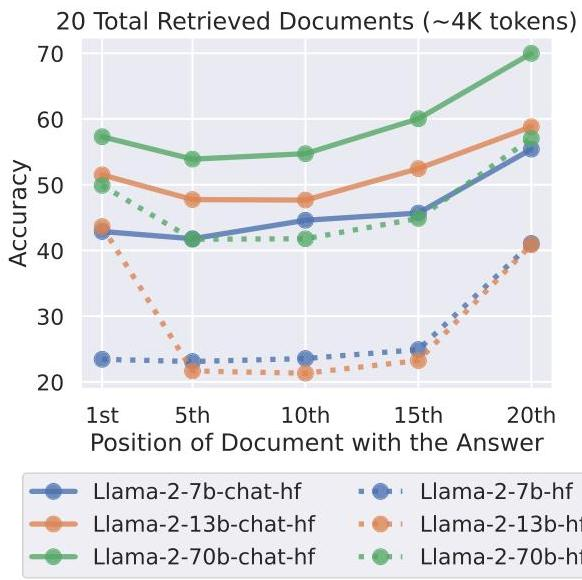
Figure 16: Multi-document QA performance (20 total documents) of Llama-2 models of varying sizes (7B, 13B, 70B parameters), with and without additional supervised fine-tuning and reinforcement learning from human feedback ("-chat-" models).

---

# F Token Counts

Table 2, Table 3, and Table 4 present the average and maximum number of tokens in each of the input contexts for all experimental settings. Note that MPT-30B and MPT-30B-Instruct use the same tokenizer, GPT-3.5-Turbo and GPT-3.5-Turbo (16K) use the same tokenizer, and Claude-1.3 and Claude-1.3 (100K) use the same tokenizer. Furthermore, the Claude-1.3 tokenizer is the same as the GPT-3.5-Turbo tokenizer, modulo some additional special tokens that do not appear in our data. As a result, the token counts for these two model families is the same in our experimental settings.

[tbl-1.html](tbl-1.html)

Table 2: Token count statistics for each of the evaluated models on the closed-book and oracle multi-document question answering settings.

[tbl-2.html](tbl-2.html)

Table 3: Token count statistics for each of the evaluated models on each of the document question answering settings.

[tbl-3.html](tbl-3.html)

Table 4: Token count statistics for each of the evaluated models on each of the key-value (KV) retrieval settings.

---

# G Full Multi-Document Question Answering Results

This section tabulates model performance when evaluated on the multi-document QA task with varying numbers of documents (Figure 5). "Index  $n$ " indicates performance when the document with the answer occurs at position  $n + 1$ , where lower indices are closer to the start of the input context. For example, index 0 refers to performance when the document with the answer is placed at the very start of the context (i.e., first amongst all documents).

# G.1 10 Total Retrieved Documents

[tbl-4.html](tbl-4.html)

# G.2 20 Total Retrieved Documents

Table 5: Model performance when evaluated on the multi-document QA task with 10 total retrieved documents.

[tbl-5.html](tbl-5.html)

# G.3 30 Total Retrieved Documents

Table 6: Model performance when evaluated on the multi-document QA task with 20 total retrieved documents.

[tbl-6.html](tbl-6.html)

Table 7: Model performance when evaluated on the multi-document QA task with 30 total retrieved documents.

In [32]:
display_result(result4)

### Display all the images

Image: img-0.jpeg position: (855,566) to (1447,1125)



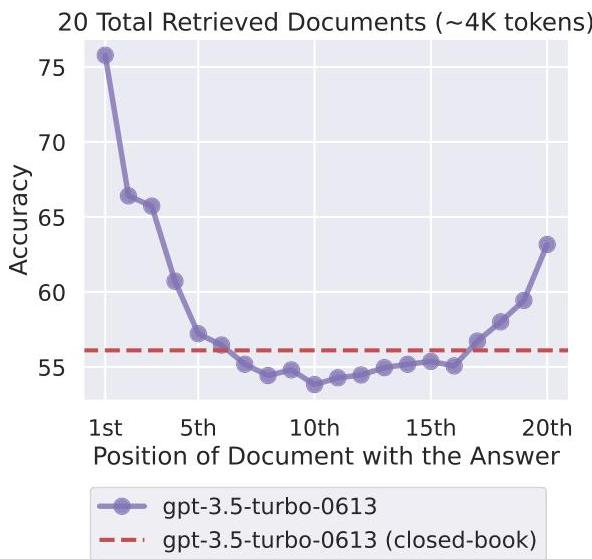

------------------------------------------------------------------------------------------------------------------------

Image: img-1.jpeg position: (262,182) to (1394,619)



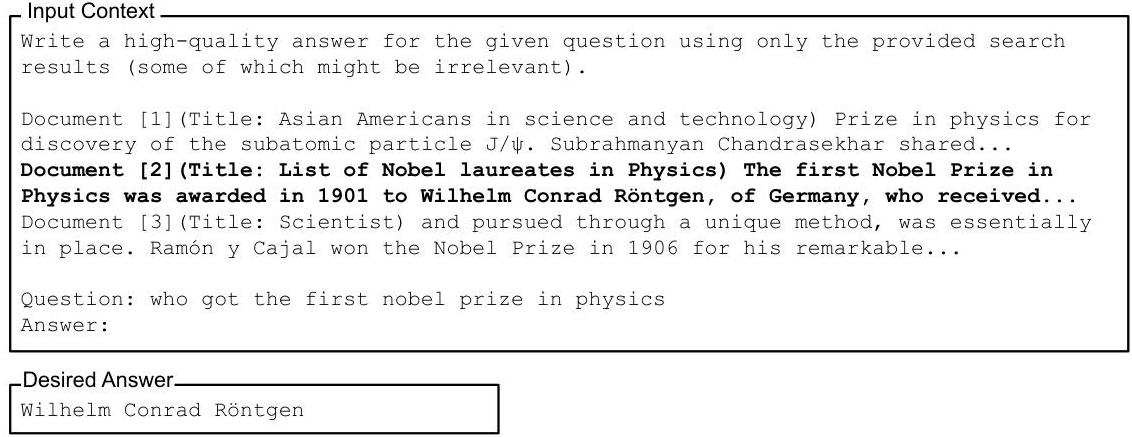

------------------------------------------------------------------------------------------------------------------------

Image: img-2.jpeg position: (226,804) to (775,1155)



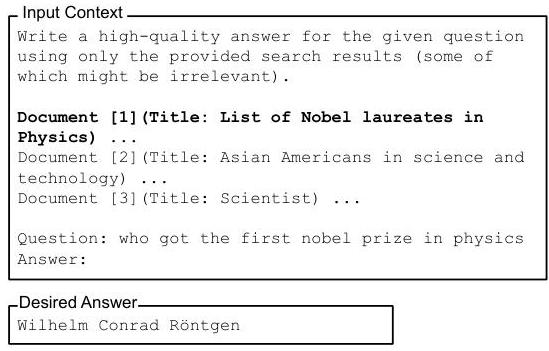

------------------------------------------------------------------------------------------------------------------------

Image: img-3.jpeg position: (879,804) to (1427,1188)



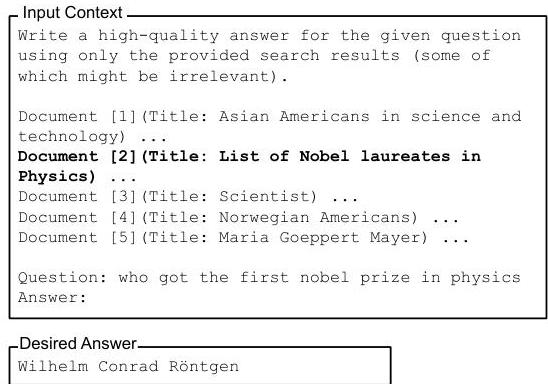

------------------------------------------------------------------------------------------------------------------------

Image: img-4.jpeg position: (196,166) to (618,486)



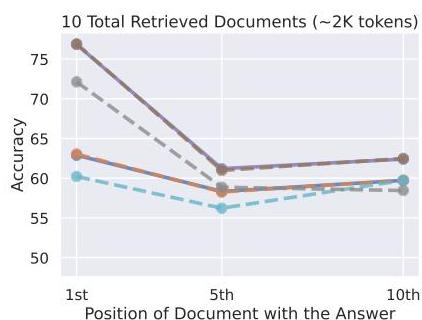

------------------------------------------------------------------------------------------------------------------------

Image: img-5.jpeg position: (618,166) to (1035,486)



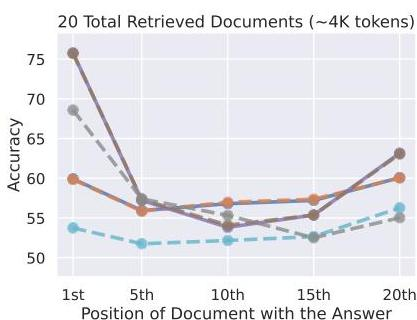

------------------------------------------------------------------------------------------------------------------------

Image: img-6.jpeg position: (1038,166) to (1455,486)



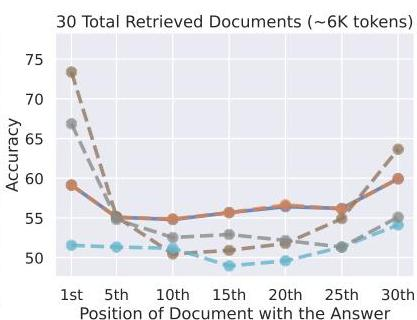

------------------------------------------------------------------------------------------------------------------------

Image: img-7.jpeg position: (269,182) to (1394,619)



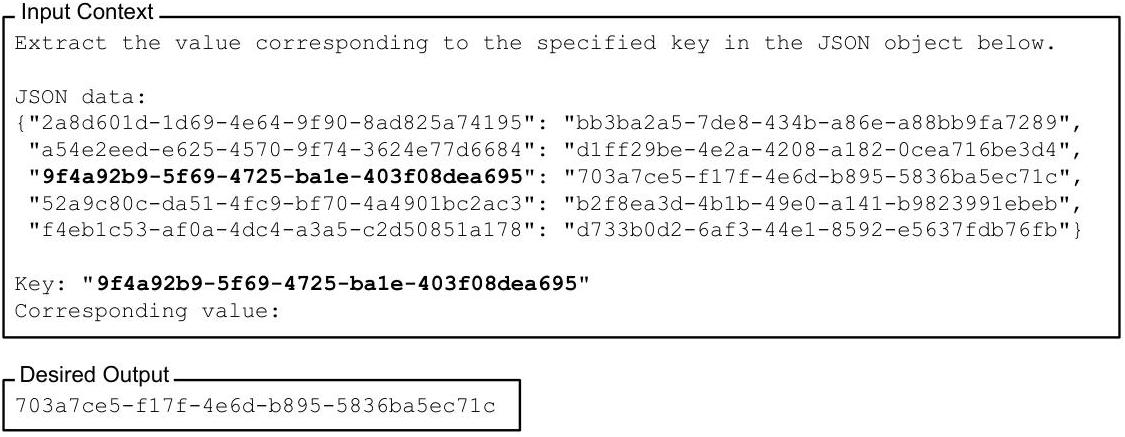

------------------------------------------------------------------------------------------------------------------------

Image: img-8.jpeg position: (196,166) to (613,488)



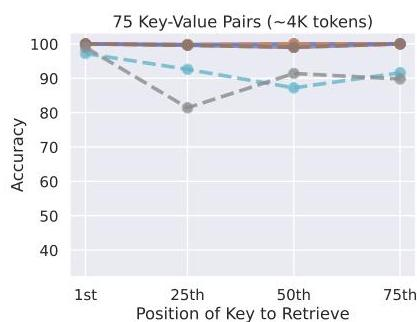

------------------------------------------------------------------------------------------------------------------------

Image: img-9.jpeg position: (613,166) to (1035,488)



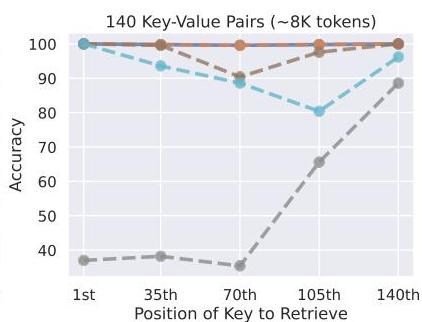

------------------------------------------------------------------------------------------------------------------------

Image: img-10.jpeg position: (1035,166) to (1455,488)



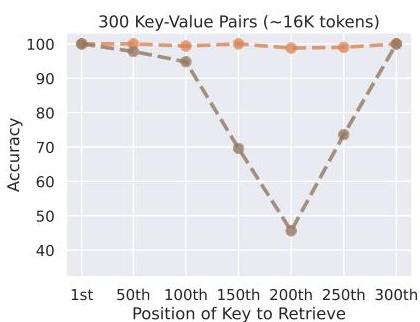

------------------------------------------------------------------------------------------------------------------------

Image: img-11.jpeg position: (196,166) to (618,491)



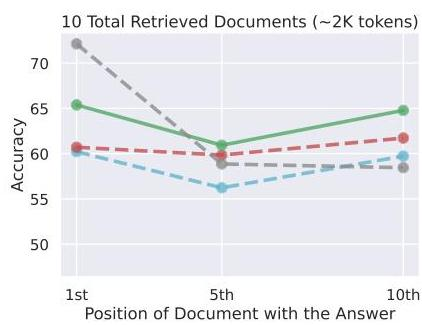

------------------------------------------------------------------------------------------------------------------------

Image: img-12.jpeg position: (618,166) to (1035,491)



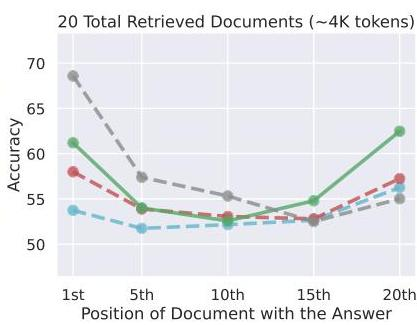

------------------------------------------------------------------------------------------------------------------------

Image: img-13.jpeg position: (1038,166) to (1455,491)



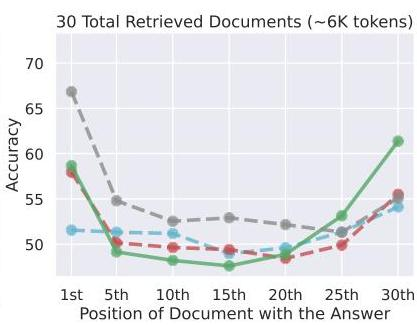

------------------------------------------------------------------------------------------------------------------------

Image: img-14.jpeg position: (236,832) to (772,1333)



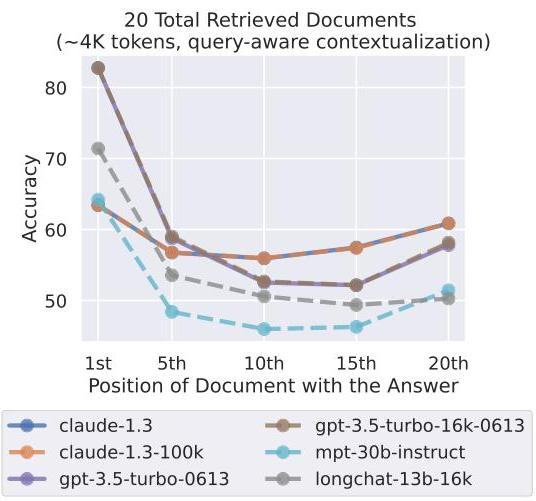

------------------------------------------------------------------------------------------------------------------------

Image: img-15.jpeg position: (229,173) to (765,650)



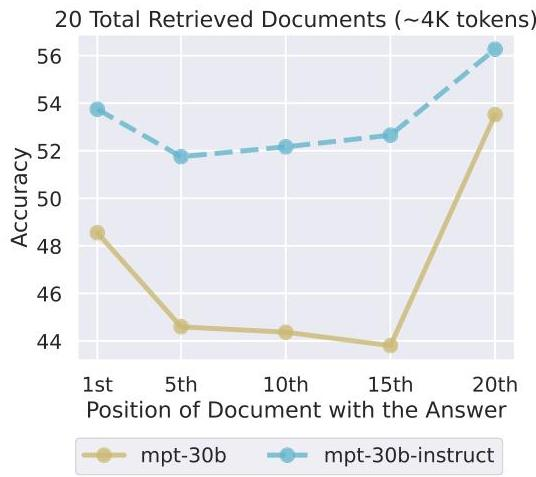

------------------------------------------------------------------------------------------------------------------------

Image: img-16.jpeg position: (238,173) to (772,647)



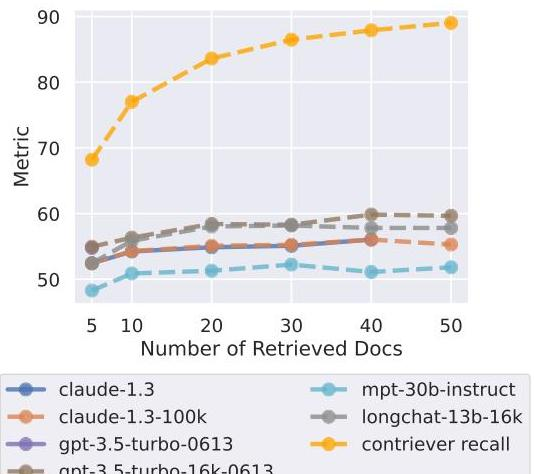

------------------------------------------------------------------------------------------------------------------------

Image: img-17.jpeg position: (858,175) to (1452,722)



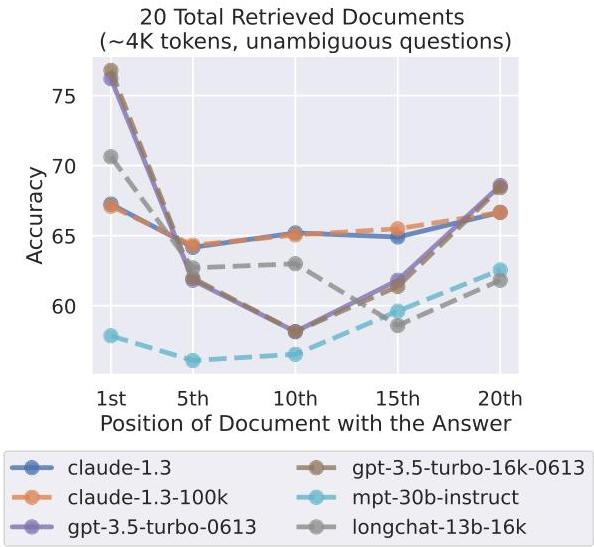

------------------------------------------------------------------------------------------------------------------------

Image: img-18.jpeg position: (205,173) to (797,722)



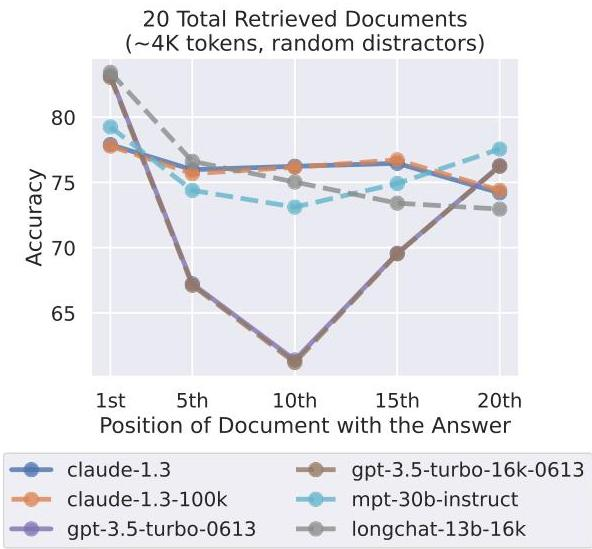

------------------------------------------------------------------------------------------------------------------------

Image: img-19.jpeg position: (855,280) to (1452,830)



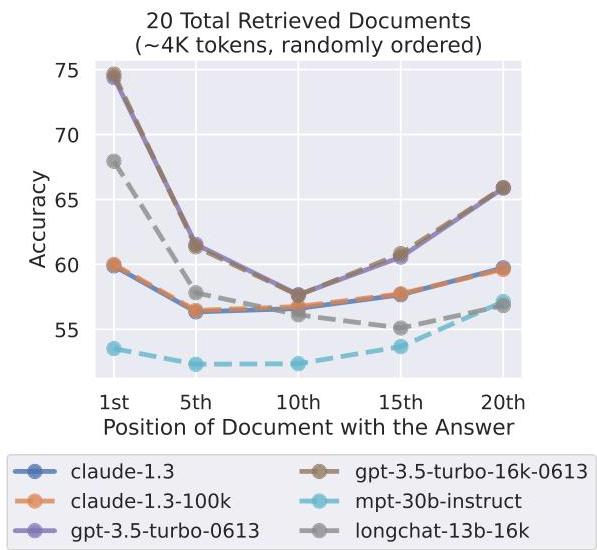

------------------------------------------------------------------------------------------------------------------------

Image: img-20.jpeg position: (855,1242) to (1452,1836)



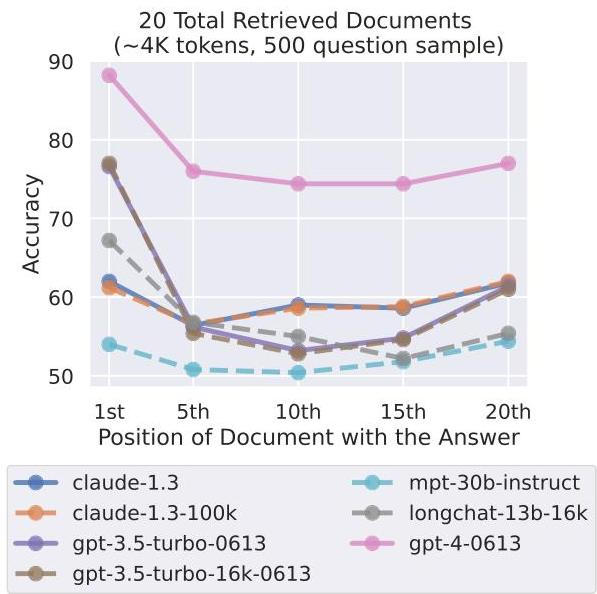

------------------------------------------------------------------------------------------------------------------------

Image: img-21.jpeg position: (855,753) to (1437,1333)



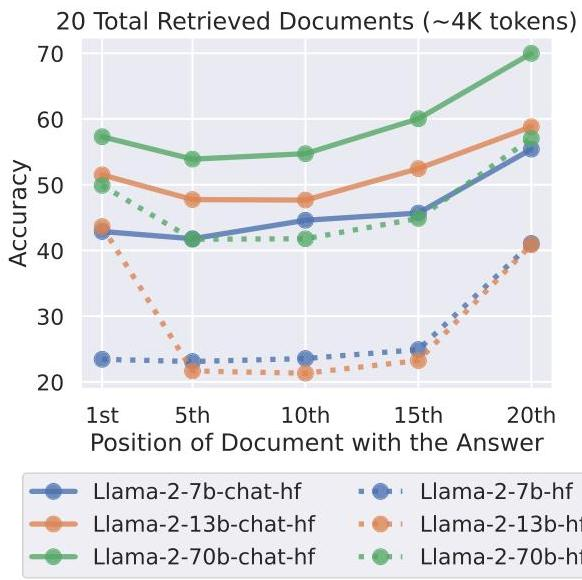

------------------------------------------------------------------------------------------------------------------------



In [33]:
for page in result4['pages']:
    for img in page['images']:
        b64_data = img['image_base64'].split(',')[1]
        print(f"Image: {img['id']} position: ({img['top_left_x']},{img['top_left_y']}) to ({img['bottom_right_x']},{img['bottom_right_y']})")
        print()
        display(Image(data=base64.b64decode(b64_data)))
        print("-" * 120)
        print()

### All the tables

In [34]:
for page in result4['pages']:
    for table in page['tables']:
        display(HTML(f"<h4>{table['id']}</h4>"))
        display(HTML(table['content']))

Model,Closed-Book,Oracle
LongChat-13B (16K),35.0%,83.4%
MPT-30B-Instruct,31.5%,81.9%
GPT-3.5-Turbo,56.1%,88.3%
GPT-3.5-Turbo (16K),56.0%,88.6%
Claude-1.3,48.3%,76.1%
Claude-1.3 (100K),48.2%,76.4%


Model,Index 0,Index 4,Index 9
Claude-1.3,62.9%,58.3%,59.7%
Claude-1.3 (100K),63.1%,58.3%,59.7%
GPT-3.5-Turbo,76.8%,61.2%,62.4%
GPT-3.5-Turbo (16K),76.9%,61.0%,62.5%
MPT-30B-Instruct,60.2%,56.2%,59.7%
LongChat-13B (16K),72.1%,58.9%,58.5%


Model,Index 0,Index 4,Index 9,Index 14,Index 19
Claude-1.3,59.9%,55.9%,56.8%,57.2%,60.1%
Claude-1.3 (100K),59.8%,55.9%,57.0%,57.4%,60.0%
GPT-3.5-Turbo,75.8%,57.2%,53.8%,55.4%,63.2%
GPT-3.5-Turbo (16K),75.7%,57.3%,54.1%,55.4%,63.1%
MPT-30B-Instruct,53.7%,51.8%,52.2%,52.7%,56.3%
LongChat-13B (16K),68.6%,57.4%,55.3%,52.5%,55.0%


Model,Index 0,Index 4,Index 9,Index 14,Index 19,Index 24,Index 29
Claude-1.3,59.1%,55.1%,54.8%,55.7%,56.4%,56.2%,59.9%
Claude-1.3 (100K),59.1%,55.1%,54.9%,55.7%,56.6%,56.1%,60.0%
GPT-3.5-Turbo (16K),73.4%,55.1%,50.5%,50.9%,51.8%,54.9%,63.7%
MPT-30B-Instruct,51.6%,51.3%,51.2%,49.0%,49.6%,51.3%,54.1%
LongChat-13B (16K),66.9%,54.8%,52.5%,52.9%,52.2%,51.3%,55.1%


In [35]:
export_json(result4, "ocr4.json")
export_md(result4, "content4.md")

Saved to results/ocr4.json
-rwxrwxrwx 1 root root 1.1M Feb 19 17:00 results/ocr4.json
Saved markdown to results/content4.md
-rwxrwxrwx 1 root root 1.1M Feb 19 17:00 results/content4.md


## 7. OCR on an Image

Mistral Document AI also processes images (PNG, JPEG, AVIF, etc.) — useful for receipts, scanned pages, photos of documents.

In [36]:
url_image = "https://github.com/Azure-Samples/document-intelligence-code-samples/blob/main/Data/receipt/receipt-with-tips.png?raw=true"

In [37]:
display(Image(url=url_image))

In [38]:
payload = {
    "model": MODEL_NAME,
    "document": make_document_payload(url_image, "image/png"),
    "include_image_base64": True
}

start = time.time()
result5 = call_mistral_ai(payload)
print(f"✅ Done in {(time.time() - start):.2f} seconds")

Downloaded and encoded (652 KB base64)
✅ Done in 1.12 seconds


In [39]:
print("\033[1;31;34m")
print(json.dumps(result5, indent=5, ensure_ascii=False))


{
     "pages": [
          {
               "index": 0,
               "images": [],
               "markdown": "# Contoso\n\nContoso\n123 Main Street\nRedmond, WA 98052\n\n987-654-3210\n\n6/10/2019 13:59\nSales Associate: Paul\n\n|  |   |\n| --- | --- |\n|  1 Cappuccino | $2.20  |\n|  1 BACON & EGGS\nSunny-side-up | $9.5  |\n|  Sub-Total | $11.70  |\n|  Tax | $1.17  |\n|  Tip | $1.63  |\n|  Total | $14.50  |",
               "footer": null,
               "header": null,
               "hyperlinks": [],
               "tables": [],
               "dimensions": {
                    "dpi": 200,
                    "height": 893,
                    "width": 1200
               }
          }
     ],
     "model": "mistral-document-ai-2512",
     "document_annotation": null,
     "usage_info": {
          "pages_processed": 1,
          "doc_size_bytes": 500950,
          "pages_processed_annotation": 0
     },
     "content_filter_results": null
}


### OCR results

In [40]:
display_result(result5, show_images=True)


Model: mistral-document-ai-2512
Pages processed: 1
Document size: 500950 bytes

📄 Page 0 (dimensions: {'dpi': 200, 'height': 893, 'width': 1200})


# Contoso

Contoso
123 Main Street
Redmond, WA 98052

987-654-3210

6/10/2019 13:59
Sales Associate: Paul

|  |   |
| --- | --- |
|  1 Cappuccino | $2.20  |
|  1 BACON & EGGS
Sunny-side-up | $9.5  |
|  Sub-Total | $11.70  |
|  Tax | $1.17  |
|  Tip | $1.63  |
|  Total | $14.50  |

In [41]:
export_json(result5, "ocr5.json")
export_md(result5, "content5.md")

Saved to results/ocr5.json
-rwxrwxrwx 1 root root 793 Feb 19 17:00 results/ocr5.json
Saved markdown to results/content5.md
-rwxrwxrwx 1 root root 280 Feb 19 17:00 results/content5.md


### Another example

In [42]:
image_file = os.path.join(DOCS_DIR, "scan.jpg")

In [43]:
display(Image(url=image_file))

In [44]:
base64_img = encode_image_to_base64(image_file)

# Detect MIME type from extension
ext = Path(image_file).suffix.lower().lstrip('.')
mime_map = {
    'png': 'image/png',
    'jpg': 'image/jpeg',
    'jpeg': 'image/jpeg',
    'avif': 'image/avif'
}
mime_type = mime_map.get(ext, 'image/png')

payload = {
    "model": MODEL_NAME,
    "document": {
        "type": "image_url",
        "image_url": f"data:{mime_type};base64,{base64_img}"
    },
    "include_image_base64": True
}

start = time.time()
result6 = call_mistral_ai(payload)
print(f"✅ Done in {(time.time() - start):.2f} seconds")

✅ Done in 2.22 seconds



{
     "pages": [
          {
               "index": 0,
               "images": [
                    {
                         "id": "img-0.jpeg",
                         "top_left_x": 42,
                         "top_left_y": 673,
                         "bottom_right_x": 181,
                         "bottom_right_y": 774,
                         "image_base64": "",
                         "image_annotation": null
                    },
                    {
                         "id": "img-1.jpeg",
                         "top_left_x": 280,
                         "top_left_y": 754,
                         "bottom_right_x": 541,
                         "bottom_right_y": 866,
                         "image_base64": "",
                         "image_annotation": null
                    }
               ],
               "markdown": "# Constat amiable d'accident automobile\n\nNe constitue pas une reconnaissance de responsabilité, mais un relevé des identités et des
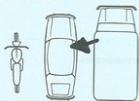
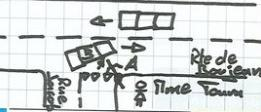

In [45]:
print("\033[1;31;34m")
print(json.dumps(result6, indent=5, ensure_ascii=False))

### OCR results


Model: mistral-document-ai-2512
Pages processed: 1
Document size: 227987 bytes

📄 Page 0 (dimensions: {'dpi': 200, 'height': 1024, 'width': 780})
Images found: 2


# Constat amiable d'accident automobile

Ne constitue pas une reconnaissance de responsabilité, mais un relevé des identités et des faits, servant à l'accélération du règlement.

à signer par les deux conducteurs

|  1. date de l'accident heure
31.02.2008 14:45 | 2. lieu, rue
Rte de Boujean 147 | 3. blessés même légers
☐ non ☑ oui  |
| --- | --- | --- |
|  4. dégâts matériels autres qu'aux véhicules A et B
☐ non ☑ oui | 5. témoins (nom, adresse et tél. – à souligner s'il s'agit d'un passager de A ou B)
Madame G. Touvu, Grunweg 13, 2500 Bienne
(suite év. au verso) |   |

## véhicule A

6. preneur d'assurance (nom et adresse)<br/>G. Padbol<br/>Chemin Vert 13<br/>2500 Bienne

No tél. (de 9 à 17 h)

Le preneur d'assurance peut-il récupérer la TVA afférente au véhicule?<br/>☐ non ☑ oui

7. véhicule<br/>marque, type<br/>plaques No<br/>châssis (matricule) No

8. assureur RC<br/>Mobilial<br/>police No 471125-7<br/>agence Bieme<br/>carte verte No (pour les étrangers) ☑<br/>valable jusqu'au<br/>assurance casco? ☐ non ☑ oui ☑<br/>Compagnie? Mobilial

9. conducteur<br/>nom Padbol<br/>prénom Gérard<br/>adresse Chemin Vert 13<br/>2500 Bienne<br/>permis de conduire: catégorie B délivré<br/>par Canton de Berne<br/>à la date du 23.03.1987

10. Indiquer par une flèche le point de choc initial

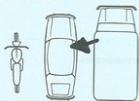

11. dégâts apparents*<br/>Vitre cassée

14. observations<br/>Le siège passager est endommagé?

A

## véhicule B

6. preneur d'assurance (nom et adresse)<br/>Jean Hemar<br/>Rue Haute 23<br/>2000 Neuchâtel

No tél. (de 9 à 17 h)

Le preneur d'assurance peut-il récupérer la TVA afférente au véhicule?<br/>☐ non ☑ oui

7. véhicule<br/>marque, type BMC, vélo de course<br/>plaques No<br/>châssis (matricule) No 443211

8. assureur RC<br/>Helvetis<br/>police No 784311<br/>agence Cortailot<br/>carte verte No (pour les étrangers) ☑<br/>valable jusqu'au<br/>assurance casco? ☐ non ☑ oui ☐<br/>Compagnie?

9. conducteur<br/>nom Jean<br/>prénom Hemar<br/>adresse Rue Haute 23<br/>2000 Neuchâtel<br/>permis de conduire: catégorie ☑ délivré<br/>par<br/>à la date du

10. Indiquer par une flèche le point de choc initial

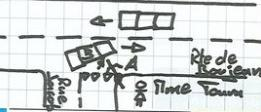

11. dégâts apparents*<br/>Roue pliée, pneu éclaté

A

14. observations<br/>Le n'a pas pu freiner!

*S'il y a des tiers lésés (dégâts matériels ou blessures) répondre aux questions No 17 et/ou 18 au verso

Ne rien modifier après les signatures et la séparation des exemplaires

Voir déclaration de l'assuré au verso

In [46]:
display_result(result6)

In [47]:
export_json(result6, "ocr6.json")
export_md(result6, "content6.md")

Saved to results/ocr6.json
-rwxrwxrwx 1 root root 18K Feb 19 17:00 results/ocr6.json
Saved markdown to results/content6.md
-rwxrwxrwx 1 root root 17K Feb 19 17:00 results/content6.md


## 8. Page Selection

You can process specific pages instead of the full document, which is useful for large PDFs.

In [48]:
# Process only specific pages (0-indexed)
payload = {
    "model": MODEL_NAME,
    "document":  make_document_payload("https://arxiv.org/pdf/2201.04234", "application/pdf"),
    "pages": [0, 1],  # Only process pages 0 and 1
    # "pages": "0-2", # Alternative: range syntax
    "include_image_base64": False
}

start = time.time()
result7 = call_mistral_ai(payload)
print(f"✅ Done in {(time.time() - start):.2f} seconds")
print(f"Pages returned: {[p['index'] for p in result7.get('pages', [])]}")

Downloaded and encoded (3909 KB base64)
✅ Done in 3.06 seconds
Pages returned: [0, 1]


### OCR results

In [49]:
display_result(result7, show_images=True)


Model: mistral-document-ai-2512
Pages processed: 2
Document size: 3002783 bytes

📄 Page 0 (dimensions: {'dpi': 200, 'height': 2200, 'width': 1700})
Hyperlinks found: 6

📄 Page 1 (dimensions: {'dpi': 200, 'height': 2200, 'width': 1700})
Images found: 2


# Leveraging Unlabeled Data to Predict Out-of-Distribution Performance

Saurabh Garg
Carnegie Mellon University
sgarg2@andrew.cmu.edu
&Sivaraman Balakrishnan
Carnegie Mellon University
sbalakri@andrew.cmu.edu
&Zachary C. Lipton
Carnegie Mellon University
zlipton@andrew.cmu.edu
&Behnam Neyshabur
Google Research, Blueshift team
neyshabur@google.com
&Hanie Sedghi
Google Research, Brain team
hsedghi@google.com

###### Abstract

Real-world machine learning deployments are characterized by mismatches between the source (training) and target (test) distributions that may cause performance drops. In this work, we investigate methods for predicting the target domain accuracy using only labeled source data and unlabeled target data. We propose Average Thresholded Confidence (ATC), a practical method that learns a threshold on the model’s confidence, predicting accuracy as the fraction of unlabeled examples for which model confidence exceeds that threshold. ATC outperforms previous methods across several model architectures, types of distribution shifts (e.g., due to synthetic corruptions, dataset reproduction, or novel subpopulations), and datasets (Wilds, ImageNet, Breeds, CIFAR, and MNIST). In our experiments, ATC estimates target performance $2$–$4\times$ more accurately than prior methods. We also explore the theoretical foundations of the problem, proving that, in general, identifying the accuracy is just as hard as identifying the optimal predictor and thus, the efficacy of any method rests upon (perhaps unstated) assumptions on the nature of the shift. Finally, analyzing our method on some toy distributions, we provide insights concerning when it works.

## 1 Introduction

Machine learning models deployed in the real world typically encounter examples from previously unseen distributions. While the IID assumption enables us to evaluate models using held-out data from the source distribution (from which training data is sampled), this estimate is no longer valid in presence of a distribution shift. Moreover, under such shifts, model accuracy tends to degrade *(Szegedy et al., 2014; Recht et al., 2019; Koh et al., 2021)*. Commonly, the only data available to the practitioner are a labeled training set (source) and unlabeled deployment-time data which makes the problem more difficult. In this setting, detecting shifts in the distribution of covariates is known to be possible (but difficult) in theory *(Ramdas et al., 2015)*, and in practice *(Rabanser et al., 2018)*. However, producing an optimal predictor using only labeled source and unlabeled target data is well-known to be impossible absent further assumptions *(Ben-David et al., 2010; Lipton et al., 2018)*.

Two vital questions that remain are: (i) the precise conditions under which we can estimate a classifier’s target-domain accuracy; and (ii) which methods are most practically useful. To begin, the straightforward way to assess the performance of a model under distribution shift would be to collect labeled (target domain) examples and then to evaluate the model on that data. However, collecting fresh labeled data from the target distribution is prohibitively expensive and time-consuming, especially if the target distribution is non-stationary. Hence, instead of using labeled data, we aim to use unlabeled data from the target distribution, that is comparatively abundant, to predict model performance. Note that in this work, our focus is not to improve performance on the target but, rather, to estimate the accuracy on the target for a given classifier.

---

Published as a conference paper at ICLR 2022

![img-0.jpeg](img-0.jpeg)
Figure 1: Illustration of our proposed method ATC. Left: using source domain validation data, we identify a threshold on a score (e.g. negative entropy) computed on model confidence such that fraction of examples above the threshold matches the validation set accuracy. ATC estimates accuracy on unlabeled target data as the fraction of examples with the score above the threshold. Interestingly, this threshold yields accurate estimates on a wide set of target distributions resulting from natural and synthetic shifts. Right: Efficacy of ATC over previously proposed approaches on our testbed with a post-hoc calibrated model. To obtain errors on the same scale, we rescale all errors with Average Confidence (AC) error. Lower estimation error is better. See Table 1 for exact numbers and comparison on various types of distribution shift. See Sec. 5 for details on our testbed.

![img-1.jpeg](img-1.jpeg)

Recently, numerous methods have been proposed for this purpose (Deng &amp; Zheng, 2021; Chen et al., 2021b; Jiang et al., 2021; Deng et al., 2021; Guillory et al., 2021). These methods either require calibration on the target domain to yield consistent estimates (Jiang et al., 2021; Guillory et al., 2021) or additional labeled data from several target domains to learn a linear regression function on a distributional distance that then predicts model performance (Deng et al., 2021; Deng &amp; Zheng, 2021; Guillory et al., 2021). However, methods that require calibration on the target domain typically yield poor estimates since deep models trained and calibrated on source data are not, in general, calibrated on a (previously unseen) target domain (Ovadia et al., 2019). Besides, methods that leverage labeled data from target domains rely on the fact that unseen target domains exhibit strong linear correlation with seen target domains on the underlying distance measure and, hence, can be rendered ineffective when such target domains with labeled data are unavailable (in Sec. 5.1 we demonstrate such a failure on a real-world distribution shift problem). Therefore, throughout the paper, we assume access to labeled source data and only unlabeled data from target domain(s).

In this work, we first show that absent assumptions on the source classifier or the nature of the shift, no method of estimating accuracy will work generally (even in non-contrived settings). To estimate accuracy on target domain perfectly, we highlight that even given perfect knowledge of the labeled source distribution (i.e.,  $p_{s}(x,y)$ ) and unlabeled target distribution (i.e.,  $p_{t}(x)$ ), we need restrictions on the nature of the shift such that we can uniquely identify the target conditional  $p_{t}(y|x)$ . Thus, in general, identifying the accuracy of the classifier is as hard as identifying the optimal predictor.

Second, motivated by the superiority of methods that use maximum softmax probability (or logit) of a model for Out-Of-Distribution (OOD) detection (Hendrycks &amp; Gimpel, 2016; Hendrycks et al., 2019), we propose a simple method that leverages softmax probability to predict model performance. Our method, Average Thresholded Confidence (ATC), learns a threshold on a score (e.g., maximum confidence or negative entropy) of model confidence on validation source data and predicts target domain accuracy as the fraction of unlabeled target points that receive a score above that threshold. ATC selects a threshold on validation source data such that the fraction of source examples that receive the score above the threshold match the accuracy of those examples. Our primary contribution in ATC is the proposal of obtaining the threshold and observing its efficacy on (practical) accuracy estimation. Importantly, our work takes a step forward in positively answering the question raised in Deng &amp; Zheng (2021); Deng et al. (2021) about a practical strategy to select a threshold that enables accuracy prediction with thresholded model confidence.

In [50]:
export_json(result7, "ocr7.json")
export_md(result7, "content7.md")

Saved to results/ocr7.json
-rwxrwxrwx 1 root root 9.0K Feb 19 17:00 results/ocr7.json
Saved markdown to results/content7.md
-rwxrwxrwx 1 root root 7.5K Feb 19 17:00 results/content7.md


## 9. BBox Annotations — Structured Image Analysis

The **BBox Annotation** feature extracts and annotates images/figures found in the document using a Vision LLM. You define a JSON schema, and the model returns structured data for each bounding box.

Use cases: describe charts, classify figure types, extract captions, convert charts to tables.

In [51]:
class ImageAnnotation(BaseModel):
    """Schema for annotating images/figures found in the document."""
    image_type: str = Field(
        ...,
        description= "The type of image (e.g., 'bar chart', 'scatter plot', 'diagram', 'photo', 'table', 'signature')"
    )
    short_description: str = Field(
        ..., 
        description="A concise description of the image content.")
    summary: str = Field(
        ...,
        description= "A detailed summary of the information conveyed by the image.")
    language: str = Field(
            ...,
        description= "What is the language of this document?")


In [52]:
# Convert to JSON schema for the API
bbox_schema = pydantic_to_json_schema(ImageAnnotation)
print("BBox Annotation Schema:")
print(json.dumps(bbox_schema, indent=2))

BBox Annotation Schema:
{
  "type": "json_schema",
  "json_schema": {
    "name": "ImageAnnotation",
    "schema": {
      "description": "Schema for annotating images/figures found in the document.",
      "properties": {
        "image_type": {
          "description": "The type of image (e.g., 'bar chart', 'scatter plot', 'diagram', 'photo', 'table', 'signature')",
          "title": "Image Type",
          "type": "string"
        },
        "short_description": {
          "description": "A concise description of the image content.",
          "title": "Short Description",
          "type": "string"
        },
        "summary": {
          "description": "A detailed summary of the information conveyed by the image.",
          "title": "Summary",
          "type": "string"
        },
        "language": {
          "description": "What is the language of this document?",
          "title": "Language",
          "type": "string"
        }
      },
      "required": [
        "imag

In [53]:
# OCR with BBox Annotations
payload = {
    "model": MODEL_NAME,
    "document": make_document_payload("https://arxiv.org/pdf/2410.07073", "application/pdf"),
    "bbox_annotation_format": bbox_schema,
    "include_image_base64": True,
    "pages": [0, 1, 2]  # First 3 pages to keep response manageable
}

start = time.time()
result8 = call_mistral_ai(payload, timeout=180)
print(f"✅ Done in {(time.time() - start):.2f} seconds")

Downloaded and encoded (16459 KB base64)
✅ Done in 6.91 seconds


In [54]:
print("\033[1;31;34m")
for page in result8['pages']:
    for img in page.get('images', []):
        print(f"Image ID: {img['id']}")
        print(f"Description: {img['image_annotation']}")


Image ID: img-0.jpeg
Description: {
  "image_type": "logo",
  "short_description": "A stylized logo of the word 'Mistral AI' in a gradient of warm colors.",
  "summary": "The image features a logo for Mistral AI. The text 'Mistral AI' is prominently displayed in a bold, three-dimensional font. The letters are rendered in a gradient of warm colors, transitioning from a bright yellow at the top to a deep brown at the bottom, giving the logo a dynamic and modern appearance. The design is simple yet striking, effectively conveying the brand name in a visually appealing manner.",
  "language": "English"
}
Image ID: img-1.jpeg
Description: {
  "image_type": "scatter plot",
  "short_description": "A scatter plot comparing the performance and cost of various AI models.",
  "summary": "The scatter plot visualizes the performance and cost of different AI models on the MM-MT-Bench. The x-axis represents the cost or number of parameters in billions (B), while the y-axis represents the performance


Image ID: img-0.jpeg
Description: {
  "image_type": "logo",
  "short_description": "A stylized logo of the word 'Mistral AI' in a gradient of warm colors.",
  "summary": "The image features a logo for Mistral AI. The text 'Mistral AI' is prominently displayed in a bold, three-dimensional font. The letters are rendered in a gradient of warm colors, transitioning from a bright yellow at the top to a deep brown at the bottom, giving the logo a dynamic and modern appearance. The design is simple yet striking, effectively conveying the brand name in a visually appealing manner.",
  "language": "English"
}


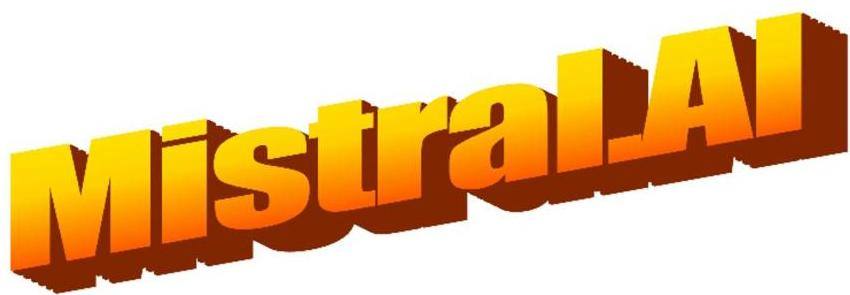

Image ID: img-1.jpeg
Description: {
  "image_type": "scatter plot",
  "short_description": "A scatter plot comparing the performance and cost of various AI models.",
  "summary": "The scatter plot visualizes the performance and cost of different AI models on the MM-MT-Bench. The x-axis represents the cost or number of parameters in billions (B), while the y-axis represents the performance. Each point on the plot corresponds to a specific AI model, with labels indicating the model names and their respective parameter sizes. The plot highlights the Pixtral 12B model as having the best performance-to-cost ratio, positioned in a shaded region indicating optimal balance. Other models such as Qwen-2-VL 72B, Llama-3.2 90B, and Molmo 72B are also plotted, showing varying performance and cost characteristics. The plot provides a comparative overview, helping to identify models that offer the best value in terms of performance relative to their cost.",
  "language": "English"
}


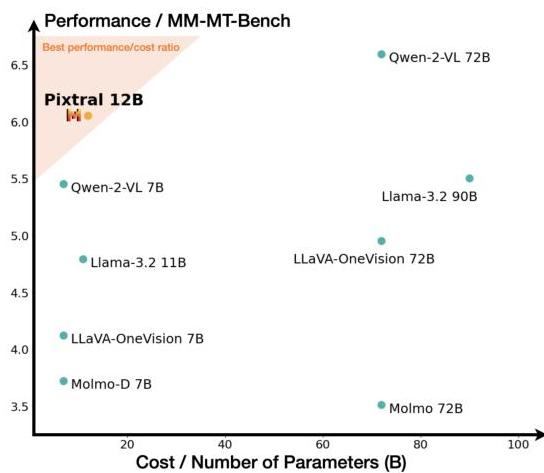

Image ID: img-2.jpeg
Description: {
  "image_type": "scatter plot",
  "short_description": "A scatter plot comparing the performance and cost of various AI models.",
  "summary": "The scatter plot visualizes the performance and cost of different AI models, with the y-axis representing performance measured by LMSys-Vision ELO and the x-axis representing cost or the number of parameters in billions. The plot highlights the Pixtral 12B model as having the best performance/cost ratio, positioned in the upper left quadrant indicating high performance with relatively low cost. Other models such as Qwen-2-VL 72B and Llama-3.2 90B are shown with higher costs but also high performance. Models like Phi-3.5-Vision and LLaVA-OneVision 72B are positioned lower on the performance scale with varying costs. The chart suggests that Pixtral 12B offers a balanced trade-off between performance and cost, making it a favorable choice among the compared models.",
  "language": "English"
}


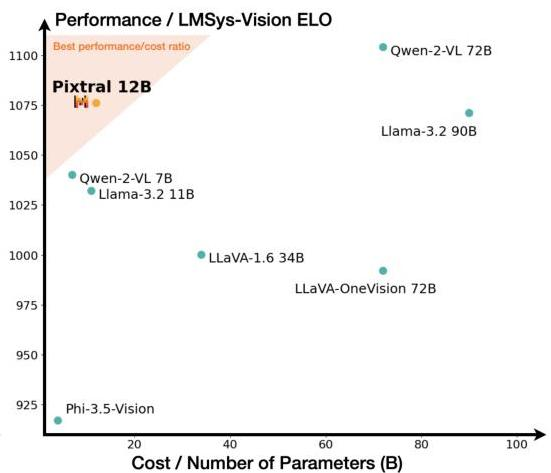

Image ID: img-3.jpeg
Description: {
  "image_type": "diagram",
  "short_description": "A diagram illustrating the architecture of the Pixtral-ViT model for vision-language tasks.",
  "summary": "The diagram provides a detailed overview of the Pixtral-ViT model architecture. It starts with image patches that are processed through RoPE-2D (Rotary Position Embedding 2D) and a block-diagonal attention mask. These patches are then fed into a bidirectional transformer. The output from the transformer is passed through a Vision-Language Projector, which aligns the visual and textual embeddings. The embeddings are further processed by a Multi-Layer Perceptron (MLP) to produce the final output embeddings. The diagram also shows the addition of special tokens [IMG_BREAK] and [IMG_END] to handle the boundaries of image data. The overall process illustrates how the model integrates visual and textual information to perform vision-language tasks.",
  "language": "English"
}


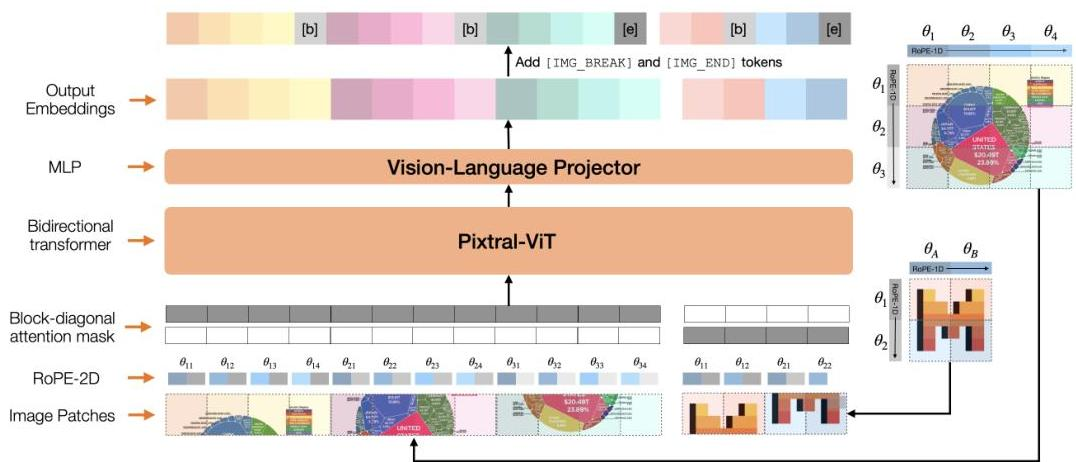

In [55]:
print("\033[1;31;34m")
for page in result8['pages']:
    for img in page.get('images', []):
        print(f"Image ID: {img['id']}")
        print(f"Description: {img['image_annotation']}")
        
        b64_data = img['image_base64']
        if b64_data.startswith('data:'):
            b64_data = b64_data.split(',', 1)[1]

        display(Image(data=base64.b64decode(b64_data)))

Image saved into: 'results/img-0.jpeg'



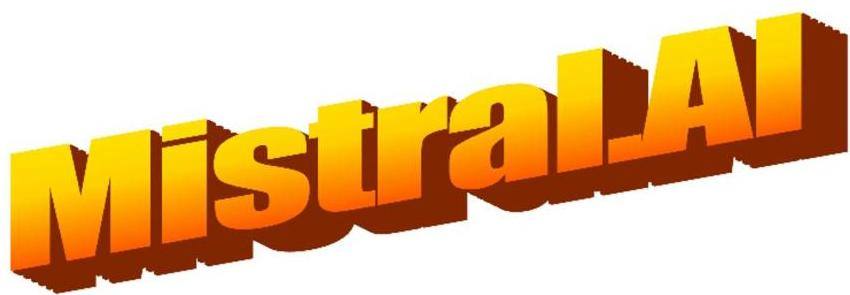

------------------------------------------------------------------------------------------------------------------------
Image saved into: 'results/img-1.jpeg'



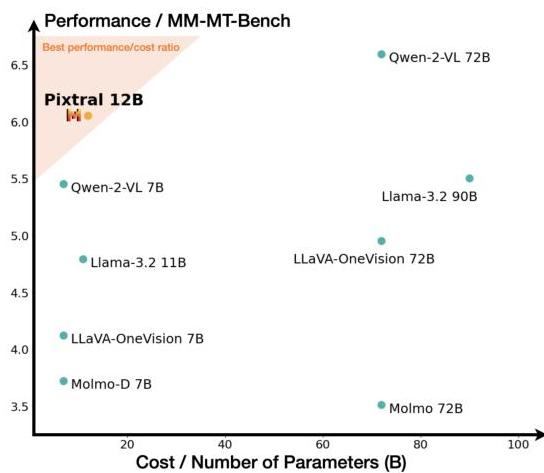

------------------------------------------------------------------------------------------------------------------------
Image saved into: 'results/img-2.jpeg'



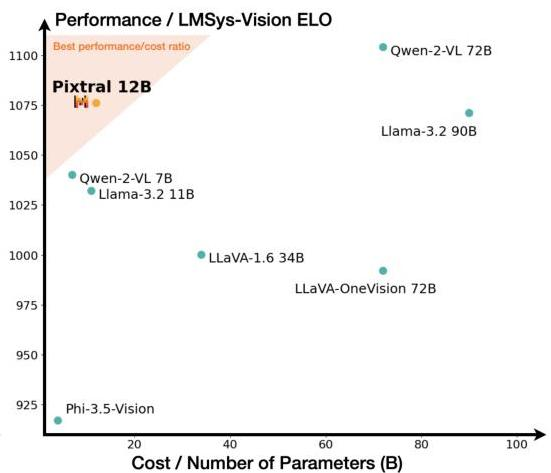

------------------------------------------------------------------------------------------------------------------------
Image saved into: 'results/img-3.jpeg'



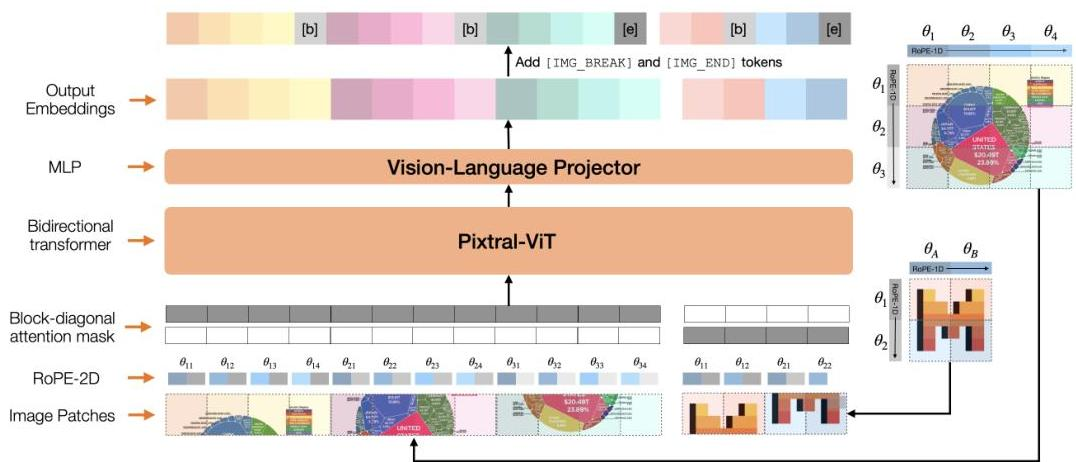

------------------------------------------------------------------------------------------------------------------------


In [56]:
for page in result8['pages']:
    for img in page.get('images', []):
        b64_data = img['image_base64']
        if b64_data.startswith('data:'):
            b64_data = b64_data.split(',', 1)[1]
        
        filepath = os.path.join(RESULTS_DIR, img['id'])
        with open(filepath, 'wb') as f:
            f.write(base64.b64decode(b64_data))
        print(f"Image saved into: '{filepath}'")
        print()
        display(Image(filename=filepath))
        print("-" * 120)

## 10. Document Annotations — Structured Data Extraction

The **Document Annotation** feature extracts structured information from the *entire document* based on a schema you define. This is the real power of Mistral Document AI — turning unstructured documents into structured JSON.

### Example: Invoice Extraction

In [57]:
# Define schemas for structured document extraction
class LineItem(BaseModel):
    description: str = Field(...,
                             description="Description of the item or service")
    quantity: Optional[float] = Field(None, description="Quantity of items")
    unit_price: Optional[float] = Field(None, description="Price per unit")
    total: Optional[float] = Field(None, description="Total amount for this line item")

In [58]:
class InvoiceData(BaseModel):
    """Schema for extracting structured data from an invoice."""
    invoice_number: Optional[str] = Field(
        None, description="The invoice number or reference")
    
    invoice_date: Optional[str] = Field(None,
                                        description="The date of the invoice")
    vendor_name: Optional[str] = Field(
        None, description="Name of the vendor or company")
    
    vendor_address: Optional[str] = Field(None,
                                          description="Address of the vendor")
    
    customer_name: Optional[str] = Field(None,
                                         description="Name of the customer")
    
    customer_address: Optional[str] = Field(
        None, description="Address of the customer")
    
    line_items: list[LineItem] = Field(
        default_factory=list, description="List of line items in the invoice")
    
    subtotal: Optional[float] = Field(None, description="Subtotal before tax")
    tax_amount: Optional[float] = Field(None, description="Tax amount")
    total_amount: Optional[float] = Field(None, description="Total amount due")
    
    currency: Optional[str] = Field(None,
                                    description="Currency (e.g., USD, EUR)")
    
    payment_terms: Optional[str] = Field(
        None, description="Payment terms or due date")

In [59]:
doc_annotation_schema = pydantic_to_json_schema(InvoiceData)

print("Document Annotation Schema (Invoice):")
print("\033[1;31;34m")
print(json.dumps(doc_annotation_schema, indent=4, default=str))

Document Annotation Schema (Invoice):

{
    "type": "json_schema",
    "json_schema": {
        "name": "InvoiceData",
        "schema": {
            "$defs": {
                "LineItem": {
                    "properties": {
                        "description": {
                            "description": "Description of the item or service",
                            "title": "Description",
                            "type": "string"
                        },
                        "quantity": {
                            "anyOf": [
                                {
                                    "type": "number"
                                },
                                {
                                    "type": "null"
                                }
                            ],
                            "default": null,
                            "description": "Quantity of items",
                            "title": "Quantity"
                   

In [60]:
invoice_pdf = os.path.join(DOCS_DIR, "invoice.pdf")

In [61]:
print(invoice_pdf)

documents/invoice.pdf


In [62]:
base64_pdf = encode_pdf_to_base64(invoice_pdf)

payload = {
    "model": MODEL_NAME,
    "document": {
        "type": "document_url",
        "document_url": f"data:application/pdf;base64,{base64_pdf}"
    },
    "document_annotation_format": doc_annotation_schema,
    "document_annotation_prompt": ("Extract all invoice information from this document. "
                                   "Include all line items with their descriptions, quantities, and amounts. "
                                   "If a field is not present in the document, set it to null."),
    "include_image_base64": False
}

start = time.time()
result9 = call_mistral_ai(payload, timeout=180)
annotation = result9.get("document_annotation")
print(f"✅ Done in {(time.time() - start):.2f} seconds")

✅ Done in 3.46 seconds


In [63]:
print("\033[1;31;34m")
print(json.dumps(result9, indent=4, default=str))


{
    "pages": [
        {
            "index": 0,
            "images": [],
            "markdown": "INVOICE\n\n# CONTOSO LTD.\n\nContoso Headquarters\n123 456th St\nNew York, NY, 10001\n\nINVOICE: INV-100\nINVOICE DATE: 11/15/2019\nDUE DATE: 12/15/2019\nCUSTOMER NAME: MICROSOFT CORPORATION\nSERVICE PERIOD: 10/14/2019 \u2013 11/14/2019\nCUSTOMER ID: CID-12345\n\nMicrosoft Corp\n123 Other St,\nRedmond WA, 98052\n\nBILL TO:\nMicrosoft Finance\n123 Bill St,\nRedmond WA, 98052\n\nSHIP TO:\nMicrosoft Delivery\n123 Ship St,\nRedmond WA, 98052\n\nSERVICE ADDRESS:\nMicrosoft Services\n123 Service St,\nRedmond WA, 98052\n\n|  SALESPERSON | P.O. NUMBER | REQUISITIONER | SHIPPED VIA | F.O.B. POINT | TERMS  |\n| --- | --- | --- | --- | --- | --- |\n|   | PO-3333 |  |  |  |   |\n|  DATE | ITEM CODE | DESCRIPTION | QTY | UM | PRICE | TAX | AMOUNT  |\n| --- | --- | --- | --- | --- | --- | --- | --- |\n|  3/4/2021 | A123 | Consulting Services | 2 | hours | $30.00 | $6.00 | $60.00  |\n|  3/5/2021 | B

In [64]:
print("\033[1;31;34m")
annotation = json.loads(result9['document_annotation'])
if annotation:
    print(json.dumps(annotation, indent=4))


{
    "invoice_number": "INV-100",
    "invoice_date": "11/15/2019",
    "vendor_name": "CONTOSO LTD.",
    "vendor_address": "Contoso Billing\n123 Remit St\nNew York, NY, 10001",
    "customer_name": "MICROSOFT CORPORATION",
    "customer_address": "Microsoft Corp\n123 Other St,\nRedmond WA, 98052",
    "line_items": [
        {
            "description": "Consulting Services",
            "quantity": 2,
            "unit_price": 30.0,
            "total": 60.0
        },
        {
            "description": "Document Fee",
            "quantity": 3,
            "unit_price": 10.0,
            "total": 30.0
        },
        {
            "description": "Printing Fee",
            "quantity": 10,
            "unit_price": 1.0,
            "total": 10.0
        }
    ],
    "subtotal": 100.0,
    "tax_amount": 10.0,
    "total_amount": 110.0,
    "currency": null,
    "payment_terms": "12/15/2019"
}


In [65]:
print("\033[1;31;34m")
if annotation:
    print("✅ Custom Extracted Invoice Data")
    invoice = InvoiceData.model_validate(annotation)
    print(f"  {'Invoice #:':<18} {invoice.invoice_number}")
    print(f"  {'Date:':<18} {invoice.invoice_date}")
    print(f"  {'Vendor:':<18} {invoice.vendor_name}")
    print(f"  {'Address:':<18} {invoice.vendor_address}")
    print(f"  {'Line items:':<18} {len(invoice.line_items)}")
    print(f"  {'Total:':<18} ${invoice.total_amount:.2f}")


✅ Custom Extracted Invoice Data
  Invoice #:         INV-100
  Date:              11/15/2019
  Vendor:            CONTOSO LTD.
  Address:           Contoso Billing
123 Remit St
New York, NY, 10001
  Line items:        3
  Total:             $110.00


In [66]:
save_annotation(result9, "invoice.json")

Saved annotation to results/invoice.json
-rwxrwxrwx 1 root root 992 Feb 19 17:00 results/invoice.json


## 11. Research Paper Extraction — Document Annotation Example

Here's an example extracting structured metadata from a research paper.

In [67]:
# Schema for research paper metadata extraction
class Author(BaseModel):
    name: str = Field(..., description="Full name of the author")
    affiliation: Optional[str] = Field(
        None, description="Author's institutional affiliation")


class PaperMetadata(BaseModel):
    """Schema for extracting metadata from a research paper."""
    title: str = Field(..., description="Title of the paper")
    authors: list[Author] = Field(default_factory=list,
                                  description="List of authors")
    abstract: Optional[str] = Field(None, description="The paper's abstract")
    keywords: list[str] = Field(default_factory=list,
                                description="Keywords or key terms")
    publication_date: Optional[str] = Field(None,
                                            description="Date of publication")
    doi: Optional[str] = Field(None, description="DOI identifier if available")
    main_contributions: list[str] = Field(
        default_factory=list,
        description="Key contributions listed in the paper")

In [68]:
paper_schema = pydantic_to_json_schema(PaperMetadata)

payload = {
    "model": MODEL_NAME,
    "document":  make_document_payload("https://arxiv.org/pdf/2307.03172", "application/pdf"),
    "document_annotation_format": paper_schema,
    "document_annotation_prompt": ("Extract the metadata from this research paper. "
                                   "Include the title, all authors with their affiliations, the abstract, "
                                   "any keywords, and the main contributions or findings described in the paper."
     ),
    "pages": [0, 1],  # Usually metadata is on the first pages
    "include_image_base64": False
}

start = time.time()
result10 = call_mistral_ai(payload, timeout=180)
annotation10 = result10.get("document_annotation")
print(f"✅ Done in {(time.time() - start):.2f} seconds")

Downloaded and encoded (973 KB base64)
✅ Done in 4.69 seconds


In [69]:
print("\033[1;31;34m")
print(json.dumps(json.loads(annotation10), indent=5, ensure_ascii=False))


{
     "title": "Lost in the Middle: How Language Models Use Long Contexts",
     "authors": [
          {
               "name": "Nelson F. Liu",
               "affiliation": "Stanford University"
          },
          {
               "name": "Kevin Lin",
               "affiliation": "University of California, Berkeley"
          },
          {
               "name": "John Hewitt",
               "affiliation": "Stanford University"
          },
          {
               "name": "Ashwin Paranjape",
               "affiliation": "Samaya AI"
          },
          {
               "name": "Michele Bevilacqua",
               "affiliation": "Samaya AI"
          },
          {
               "name": "Fabio Petroni",
               "affiliation": "Samaya AI"
          },
          {
               "name": "Percy Liang",
               "affiliation": "Stanford University"
          }
     ],
     "abstract": "While recent language models have the ability to take long contexts as inpu

In [70]:
save_annotation(result10, "annotation10.json")

Saved annotation to results/annotation10.json
-rwxrwxrwx 1 root root 2.4K Feb 19 17:00 results/annotation10.json


## 12. Combined BBox + Document Annotations

You can use both annotation types simultaneously: annotate images *and* extract structured document data in a single call.

In [71]:
# Combined annotations
payload = {
    "model": MODEL_NAME,
    "document": make_document_payload("https://arxiv.org/pdf/2410.07073", "application/pdf"),
    "bbox_annotation_format": pydantic_to_json_schema(ImageAnnotation),
    "document_annotation_format": pydantic_to_json_schema(PaperMetadata),
    "document_annotation_prompt": "Extract complete paper metadata.",
    "pages": [0, 1],
    "include_image_base64": False
}

start = time.time()
result_combined = call_mistral_ai(payload, timeout=240)
result11 = result_combined.get("document_annotation")
print(f"✅ Done in {(time.time() - start):.2f} seconds")

Downloaded and encoded (16459 KB base64)
✅ Done in 9.09 seconds


In [72]:
print("\033[1;31;34m")
print(json.dumps(json.loads(result11), indent=5, ensure_ascii=False))


{
     "title": "Pixtral 12B",
     "authors": [
          {
               "name": "Mistral AI"
          }
     ],
     "abstract": "We introduce Pixtral 12B, a 12-billion-parameter multimodal language model. Pixtral 12B is trained to understand both natural images and documents, achieving leading performance on various multimodal benchmarks, surpassing a number of larger models. Unlike many open-source models, Pixtral is also a cutting-edge text model for its size, and does not compromise on natural language performance to excel in multimodal tasks. Pixtral uses a new vision encoder trained from scratch, which allows it to ingest images at their natural resolution and aspect ratio. This gives users flexibility on the number of tokens used to process an image. Pixtral is also able to process any number of images in its long context window of 128K tokens. Pixtral 12B substantially outperforms other open models of similar sizes (Llama-3.2 11B & Qwen-2-VL 7B). It also outperforms much 

## 13. Saved results

In [73]:
!ls $RESULTS_DIR -lh

total 3.2M
-rwxrwxrwx 1 root root 2.4K Feb 19 17:00 annotation10.json
-rwxrwxrwx 1 root root 330K Feb 19 16:59 content1.md
-rwxrwxrwx 1 root root 109K Feb 19 17:00 content3.md
-rwxrwxrwx 1 root root 1.1M Feb 19 17:00 content4.md
-rwxrwxrwx 1 root root  280 Feb 19 17:00 content5.md
-rwxrwxrwx 1 root root  17K Feb 19 17:00 content6.md
-rwxrwxrwx 1 root root 7.5K Feb 19 17:00 content7.md
-rwxrwxrwx 1 root root  20K Feb 19 17:00 img-0.jpeg
-rwxrwxrwx 1 root root  22K Feb 19 17:00 img-1.jpeg
-rwxrwxrwx 1 root root  22K Feb 19 17:00 img-2.jpeg
-rwxrwxrwx 1 root root  59K Feb 19 17:00 img-3.jpeg
-rwxrwxrwx 1 root root  992 Feb 19 17:00 invoice.json
-rwxrwxrwx 1 root root 336K Feb 19 16:59 ocr1.json
-rwxrwxrwx 1 root root 128K Feb 19 17:00 ocr3.json
-rwxrwxrwx 1 root root 1.1M Feb 19 17:00 ocr4.json
-rwxrwxrwx 1 root root  793 Feb 19 17:00 ocr5.json
-rwxrwxrwx 1 root root  18K Feb 19 17:00 ocr6.json
-rwxrwxrwx 1 root root 9.0K Feb 19 17:00 ocr7.json
